# Feedforward Neural Network (FFNN) Testing

13522029
13522043
13522093

In [8]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm.notebook import tqdm
from sklearn.neural_network import MLPClassifier

sys.path.append(os.path.abspath('..'))

from src.models.ffnn import FFNN
from src.models.activations import get_activation
from src.models.losses import get_loss
from src.models.initializers import get_initializer
from src.models.utils import (
    plot_training_history, plot_weight_distribution, 
    plot_network_graph, one_hot_encode, batch_iterator
)


Load dataset

In [9]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, parser='auto')

# ensure correct data types
X = X.to_numpy().astype(np.float32)
y = y.to_numpy().astype(np.int32)

# Normalize pixel values to [0, 1]
X = X / 255.0

print(f"MNIST dataset loaded:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")

MNIST dataset loaded:
X shape: (70000, 784)
y shape: (70000,)
Number of classes: 10


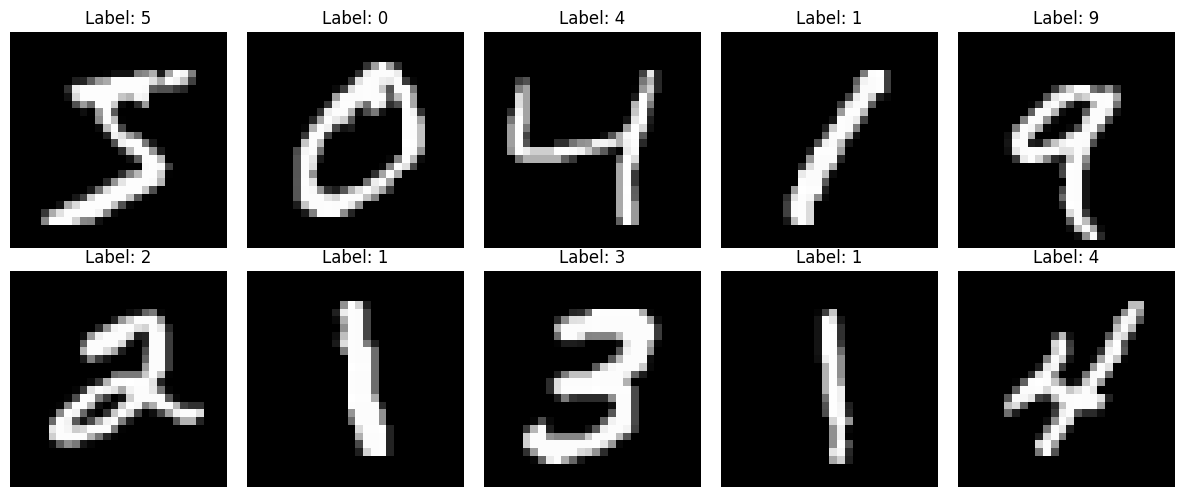

In [10]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [11]:
n_samples = 50000  # Berapa data
X_subset = X[:n_samples]
y_subset = y[:n_samples]

X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42
)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# one hot encode multiclass class
y_train_one_hot = one_hot_encode(y_train)
y_test_one_hot = one_hot_encode(y_test)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
# print(f"One-hot encoded labels shape: {y_train_one_hot.shape}")

Training data shape: (40000, 784)
Testing data shape: (10000, 784)


In [12]:
def plot_comparison(histories, title="Model Comparison", metric="train_loss"):
    plt.figure(figsize=(12, 5))
    
    for name, history in histories.items():
        if metric in history and history[metric] is not None:
            plt.plot(history[metric], label=name)
    
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss" if "loss" in metric else "Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def evaluate_model(model, X_test, y_test, y_test_one_hot):
    y_pred = model.predict(X_test)
    
    if model.activations[-1].name() == "Softmax":
        y_pred_class = np.argmax(y_pred, axis=1)
    else:
        y_pred_class = np.round(y_pred).astype(int)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred_class)
    print(f"Test accuracy: {accuracy:.4f}")
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred_class)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix (Accuracy: {accuracy:.4f})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    return accuracy

## Depth and Width Experiments

In [13]:
# Parameter eksperimen
learning_rate = 0.01
batch_size = 64
epochs = 20  # increase / decrease sesuaikan (sekarang 20 utk eksperimen)

models = {}
histories = {}


--- Width Experiments ---

Training model with width=64


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 286.96it/s]


Epoch 1/20 - 2.23s - loss: 1.2897 - val_loss: 0.6594 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 288.28it/s]


Epoch 2/20 - 2.22s - loss: 0.4811 - val_loss: 0.4122 - lr: 0.010000


...

Epoch 18/20 - 2.23s - loss: 0.1015 - val_loss: 0.1877 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 284.48it/s]


Epoch 19/20 - 2.24s - loss: 0.0967 - val_loss: 0.1863 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 285.65it/s]


Epoch 20/20 - 2.23s - loss: 0.0922 - val_loss: 0.1856 - lr: 0.010000

Evaluation for width_narrow:
Test accuracy: 0.9525


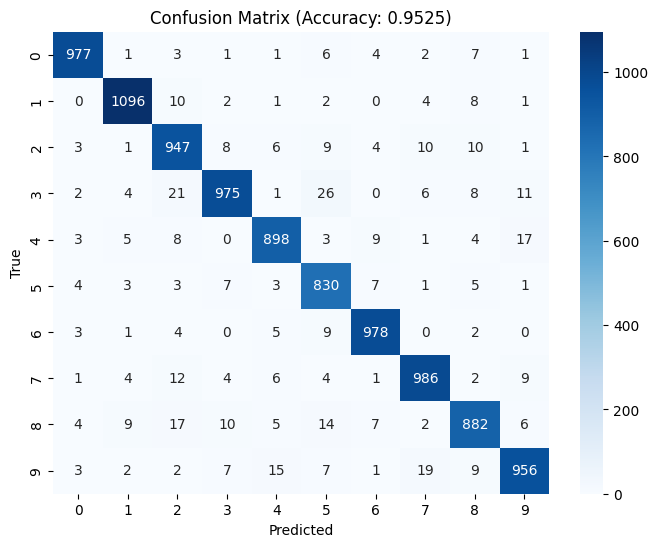


Weight distribution for width_narrow:


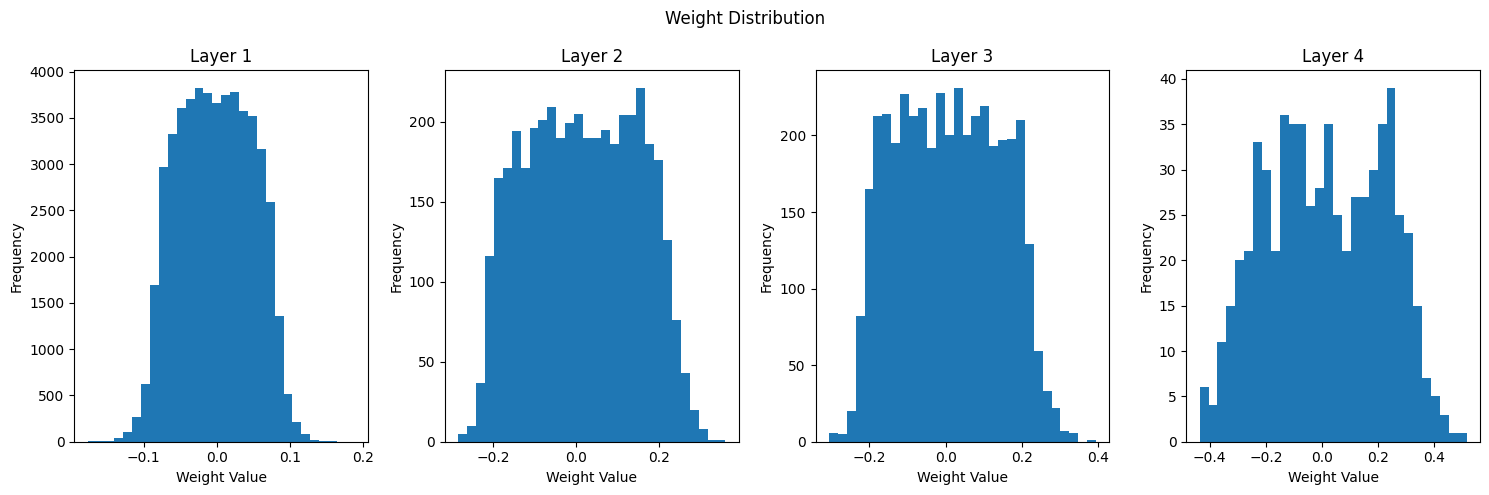


Gradient distribution for width_narrow:


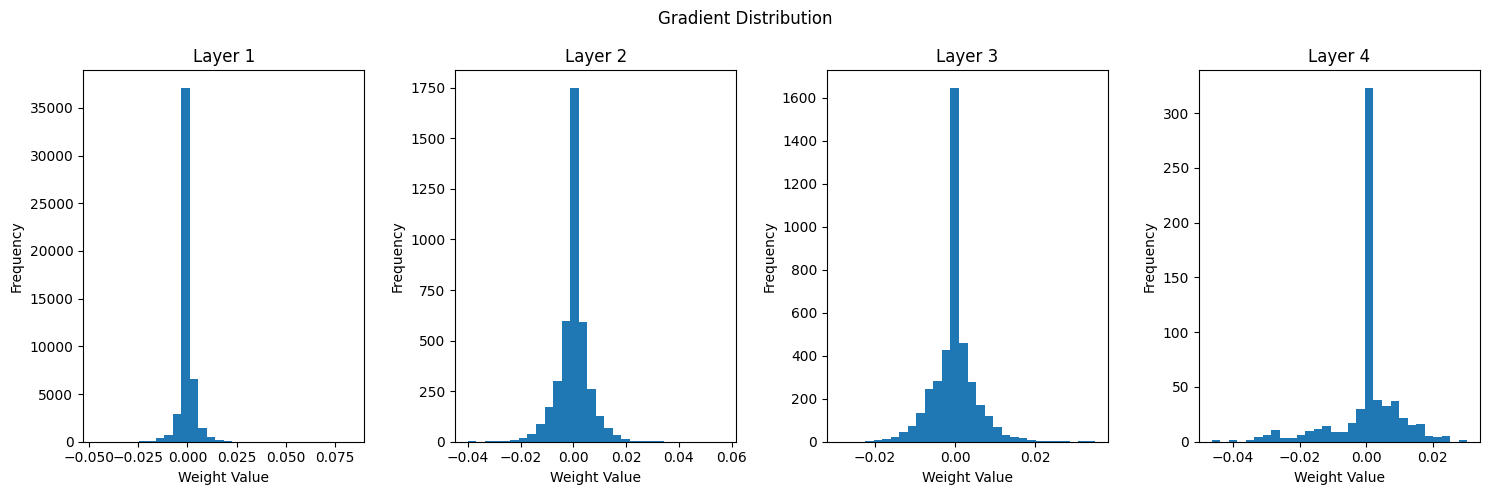


Training model with width=128


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 217.16it/s]


Epoch 1/20 - 2.96s - loss: 1.2807 - val_loss: 0.6243 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 222.70it/s]


Epoch 2/20 - 2.88s - loss: 0.4633 - val_loss: 0.3869 - lr: 0.010000


...

Epoch 18/20 - 2.78s - loss: 0.0832 - val_loss: 0.1653 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 226.12it/s]


Epoch 19/20 - 2.84s - loss: 0.0777 - val_loss: 0.1624 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 230.54it/s]


Epoch 20/20 - 2.79s - loss: 0.0732 - val_loss: 0.1621 - lr: 0.010000

Evaluation for width_medium:
Test accuracy: 0.9567


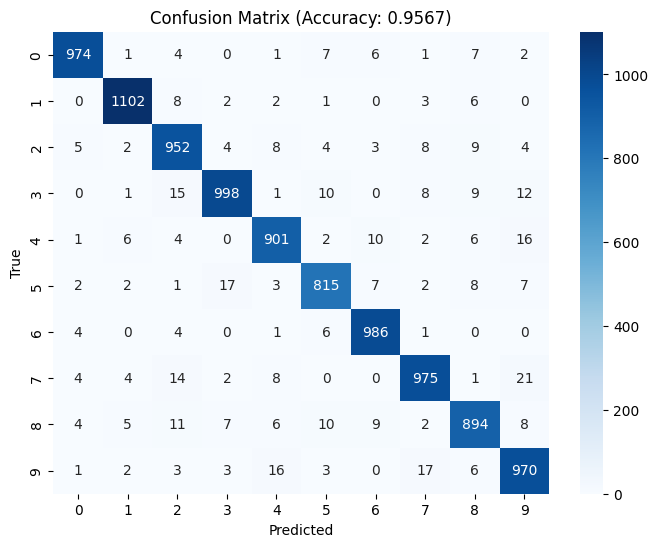


Weight distribution for width_medium:


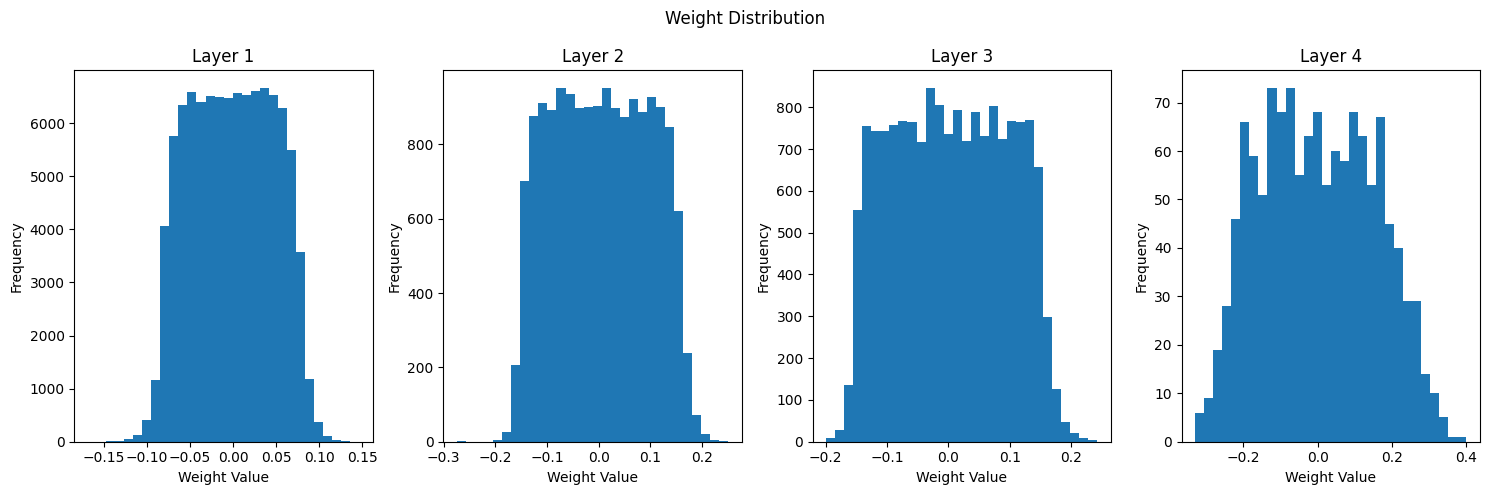


Gradient distribution for width_medium:


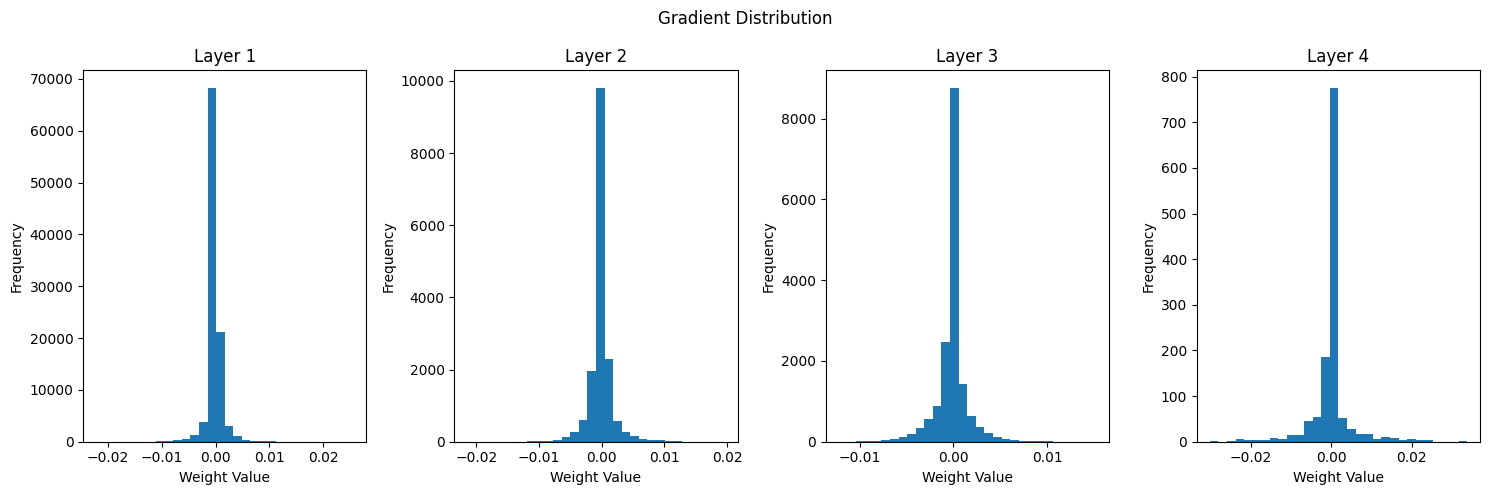


Training model with width=256


Epoch 1/20: 100%|██████████| 625/625 [00:04<00:00, 141.76it/s]


Epoch 1/20 - 4.53s - loss: 1.1902 - val_loss: 0.5556 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:04<00:00, 145.11it/s]


Epoch 2/20 - 4.45s - loss: 0.4199 - val_loss: 0.3660 - lr: 0.010000


...

Epoch 18/20 - 4.27s - loss: 0.0707 - val_loss: 0.1640 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:04<00:00, 150.28it/s]


Epoch 19/20 - 4.30s - loss: 0.0655 - val_loss: 0.1639 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:04<00:00, 147.82it/s]


Epoch 20/20 - 4.35s - loss: 0.0608 - val_loss: 0.1625 - lr: 0.010000

Evaluation for width_wide:
Test accuracy: 0.9582


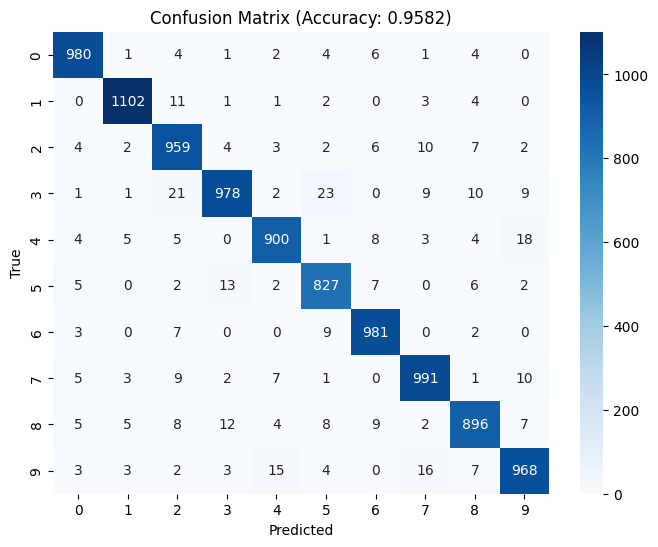


Weight distribution for width_wide:


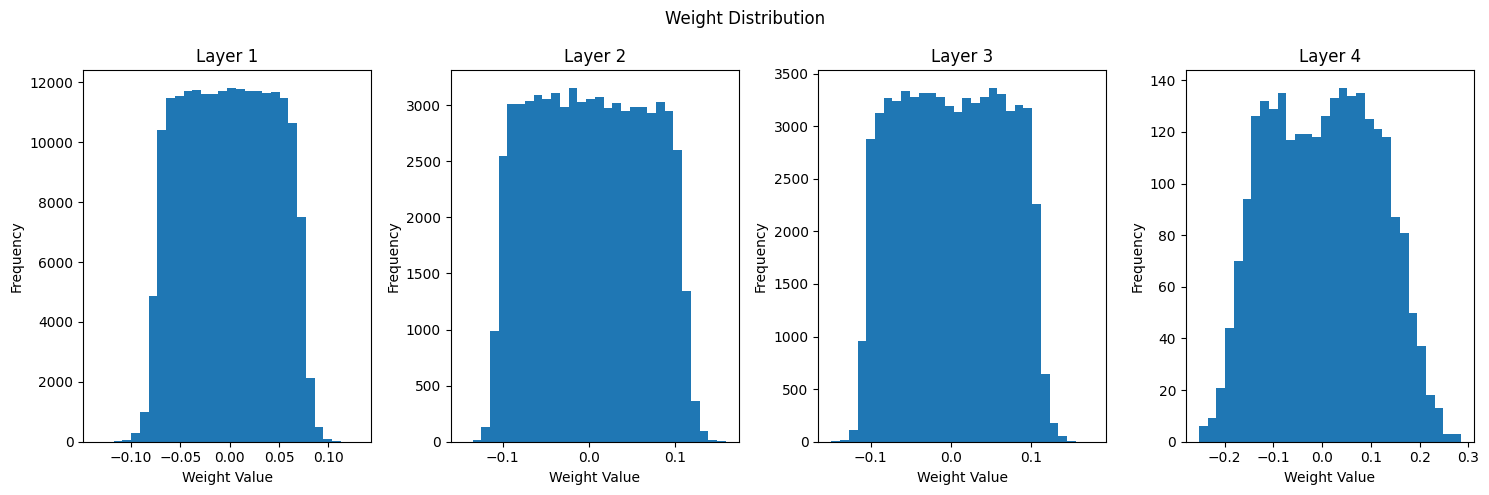


Gradient distribution for width_wide:


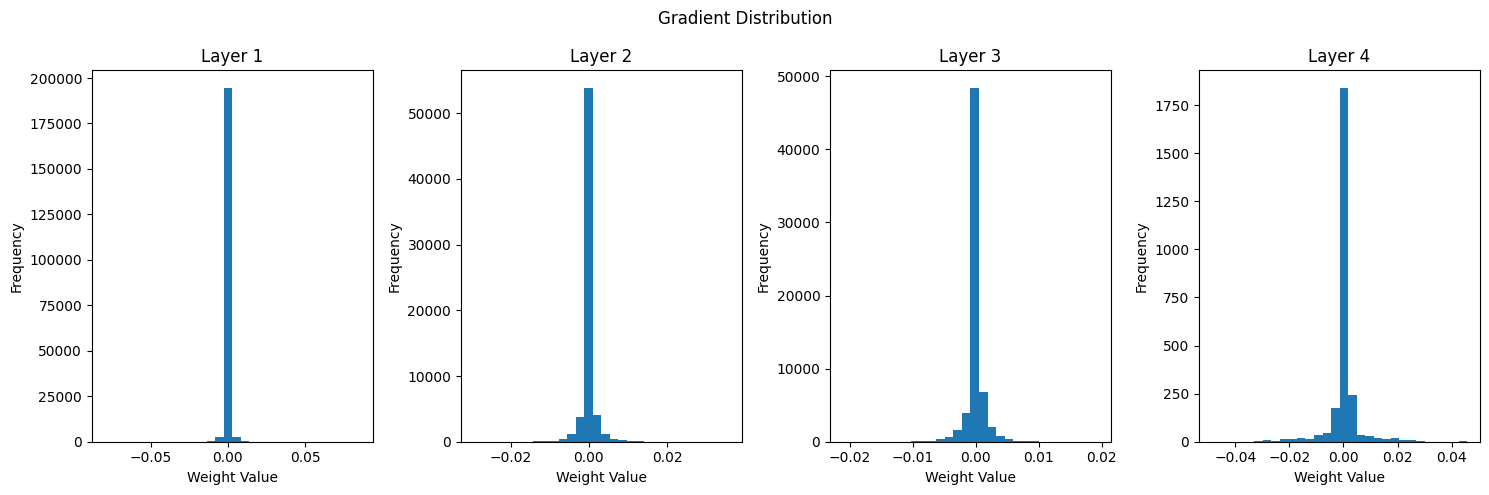

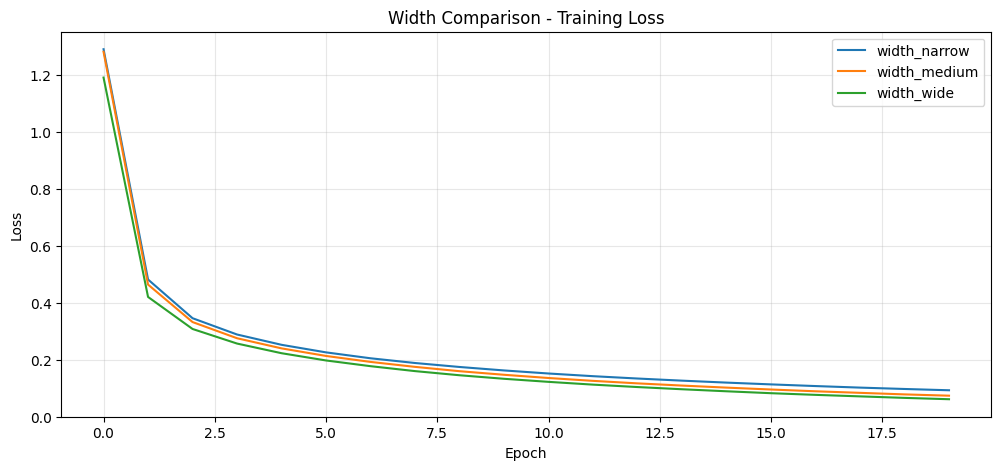

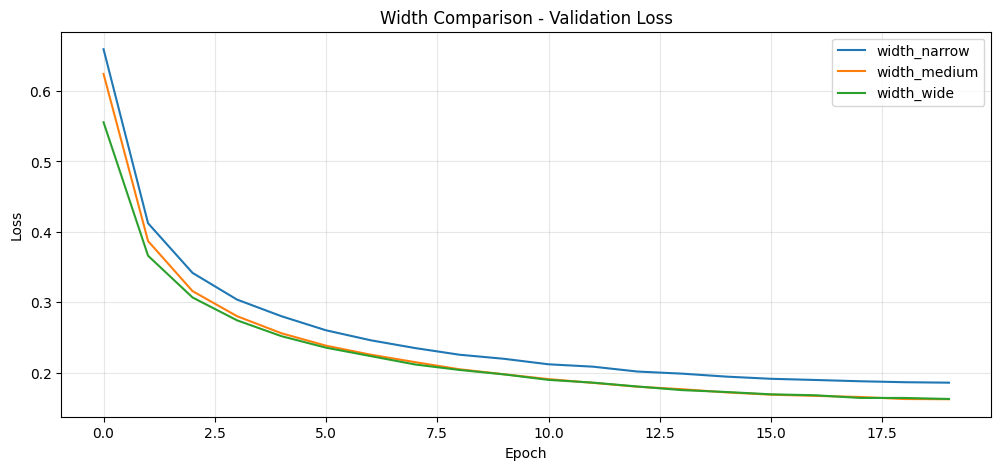

In [14]:
# Width
width_variations = [
    {'name': 'narrow', 'hidden_units': 64},
    {'name': 'medium', 'hidden_units': 128},
    {'name': 'wide', 'hidden_units': 256}
]

print("\n--- Width Experiments ---")
for variation in width_variations:
    hidden_units = variation['hidden_units']
    name = f"width_{variation['name']}"
    
    layer_sizes = [784, hidden_units, hidden_units, hidden_units, 10]
    
    print(f"\nTraining model with width={hidden_units}")
    model = FFNN(
        layer_sizes=layer_sizes,
        activations=['relu', 'relu', 'relu', 'softmax'],
        loss='categorical_cross_entropy',
        weight_initializer='xavier',
        # use_rms_norm=True
    )
    
    # Use the built-in fit method instead of manual training loop
    history = model.fit(
        X_train, 
        y_train_one_hot,
        batch_size=batch_size,
        learning_rate=learning_rate,
        epochs=epochs,
        verbose=1,
        validation_data=(X_test, y_test_one_hot)
    )
    
    models[name] = model
    histories[name] = history
    
    # Evaluate model
    print(f"\nEvaluation for {name}:")
    evaluate_model(model, X_test, y_test, y_test_one_hot)

    has_nan_weights = any(np.isnan(w).any() for w in model.weights)
    has_nan_gradients = any(np.isnan(g).any() for g in model.weight_gradients)
    
    # Plot weight distribution
    print(f"\nWeight distribution for {name}:")
    # model.plot_weight()
    if has_nan_weights:
        print("cant plot weight distribution due to NaN values")
    else:
        model.plot_weight()
    
    # Plot gradient distribution
    print(f"\nGradient distribution for {name}:")
    # model.plot_gradient_distribution()
    if has_nan_gradients:
        print("ant plot gradient distribution due to NaN values")
    else:
        model.plot_gradient_distribution()
    
plot_comparison(histories, "Width Comparison - Training Loss", "train_loss")
plot_comparison(histories, "Width Comparison - Validation Loss", "val_loss")


--- Depth Experiments ---

Training model with depth=1 (hidden layers)


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 268.44it/s]


Epoch 1/20 - 2.38s - loss: 1.1533 - val_loss: 0.5756 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 278.52it/s]


Epoch 2/20 - 2.30s - loss: 0.4426 - val_loss: 0.4059 - lr: 0.010000


...

Epoch 18/20 - 2.26s - loss: 0.1118 - val_loss: 0.1780 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 284.87it/s]


Epoch 19/20 - 2.24s - loss: 0.1071 - val_loss: 0.1748 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 283.58it/s]


Epoch 20/20 - 2.26s - loss: 0.1027 - val_loss: 0.1720 - lr: 0.010000

Evaluation for depth_shallow:
Test accuracy: 0.9539


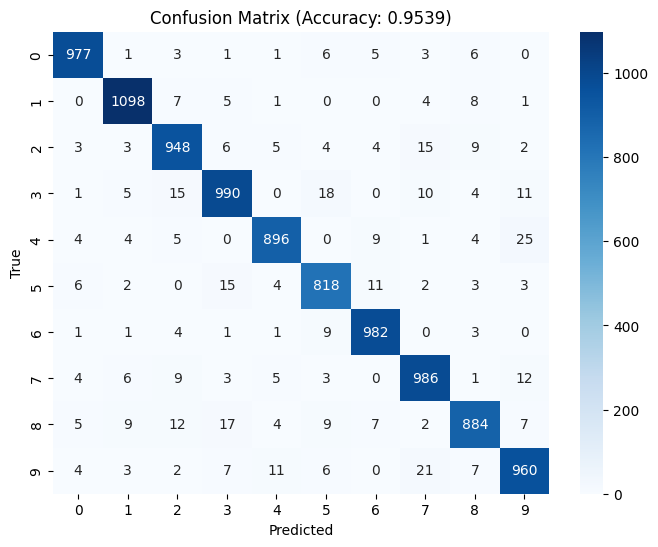


Weight distribution for depth_shallow:


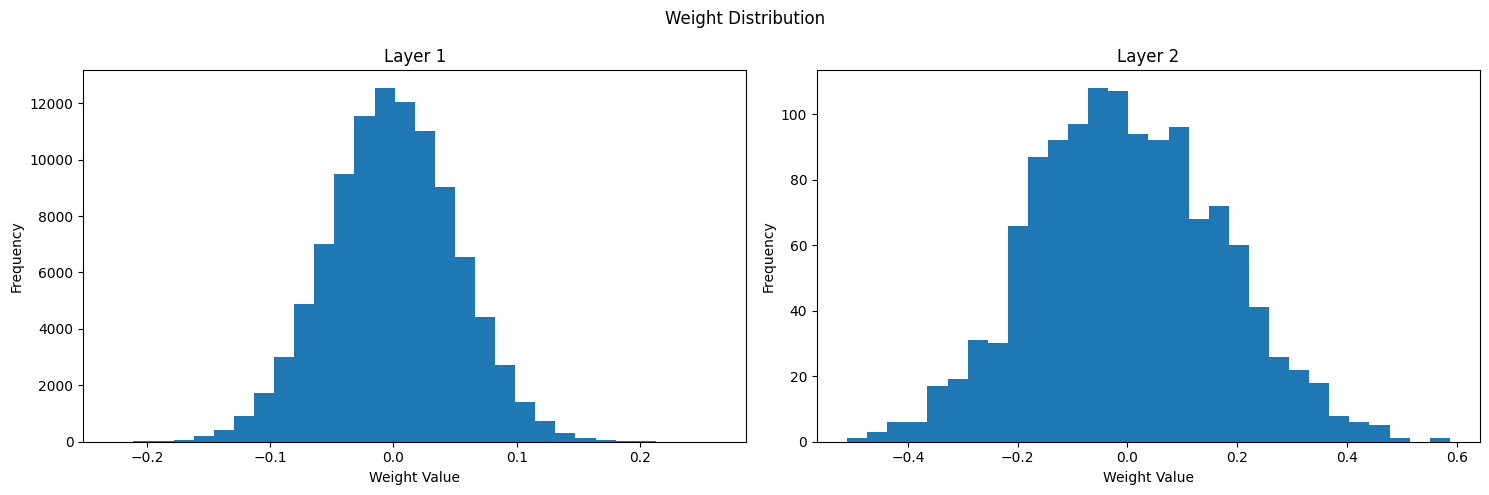


Gradient distribution for depth_shallow:


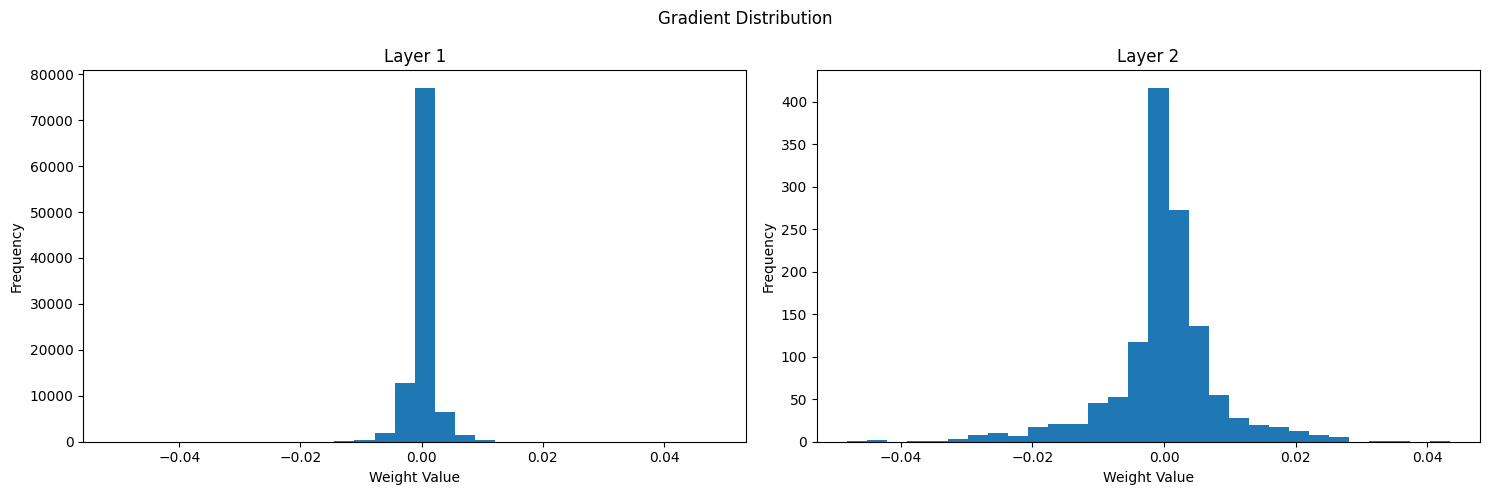


Training model with depth=4 (hidden layers)


Epoch 1/20: 100%|██████████| 625/625 [00:03<00:00, 192.84it/s]


Epoch 1/20 - 3.36s - loss: 1.3137 - val_loss: 0.6838 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:03<00:00, 196.11it/s]


Epoch 2/20 - 3.27s - loss: 0.5058 - val_loss: 0.4470 - lr: 0.010000


...

Epoch 18/20 - 3.11s - loss: 0.0746 - val_loss: 0.1838 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 210.58it/s]


Epoch 19/20 - 3.07s - loss: 0.0695 - val_loss: 0.1853 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:03<00:00, 200.71it/s]


Epoch 20/20 - 3.21s - loss: 0.0648 - val_loss: 0.1858 - lr: 0.010000

Evaluation for depth_medium:
Test accuracy: 0.9552


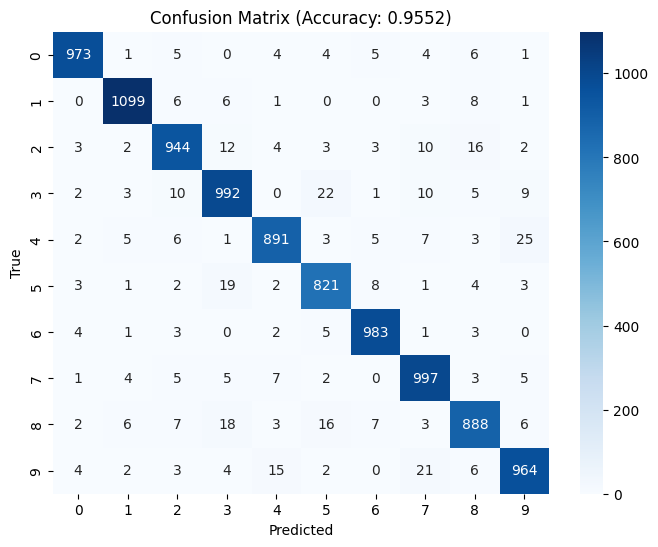


Weight distribution for depth_medium:


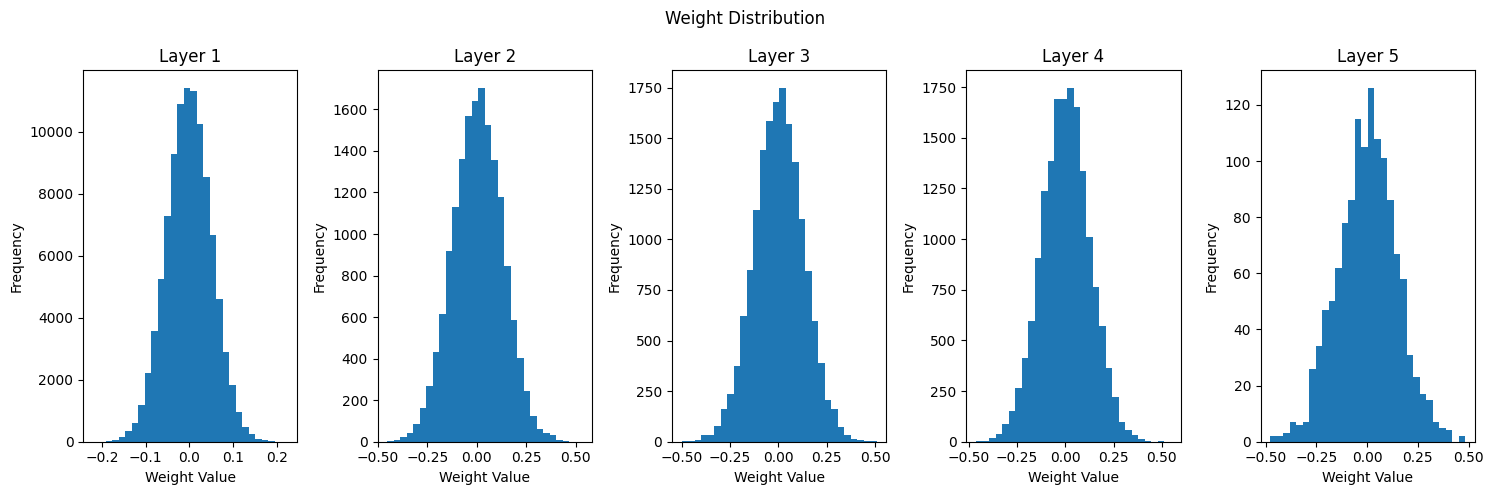


Gradient distribution for depth_medium:


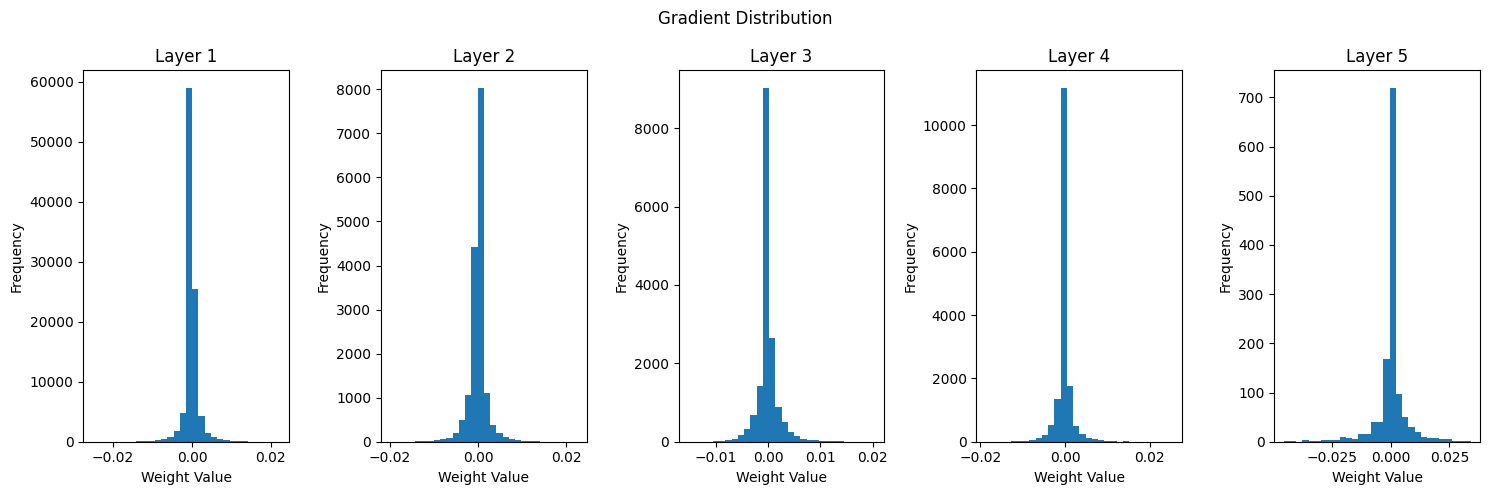


Training model with depth=8 (hidden layers)


Epoch 1/20: 100%|██████████| 625/625 [00:04<00:00, 150.42it/s]


Epoch 1/20 - 4.28s - loss: 1.5417 - val_loss: 0.8752 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:04<00:00, 146.37it/s]


Epoch 2/20 - 4.42s - loss: 0.6517 - val_loss: 0.5422 - lr: 0.010000


...

Epoch 18/20 - 4.63s - loss: 0.0910 - val_loss: 0.2474 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:04<00:00, 147.12it/s]


Epoch 19/20 - 4.40s - loss: 0.0844 - val_loss: 0.2535 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:04<00:00, 143.65it/s]


Epoch 20/20 - 4.49s - loss: 0.0782 - val_loss: 0.2520 - lr: 0.010000

Evaluation for depth_deep:
Test accuracy: 0.9420


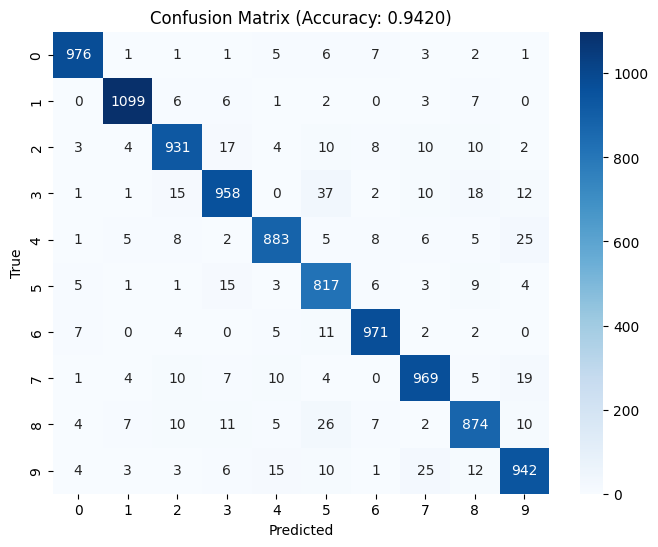


Weight distribution for depth_deep:


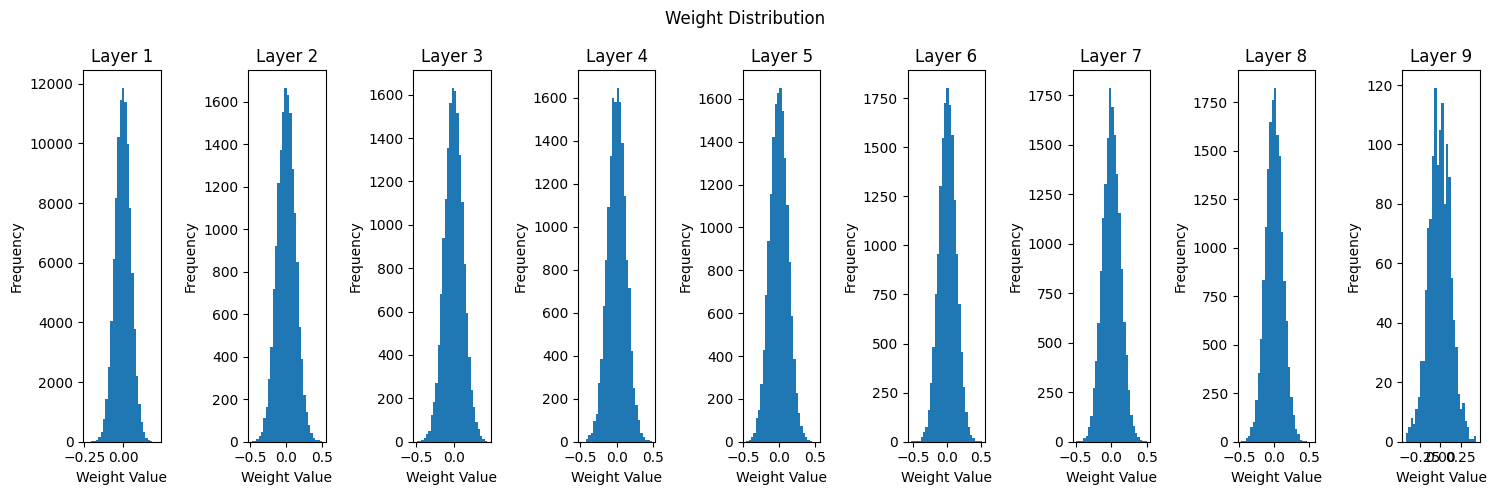


Gradient distribution for depth_deep:


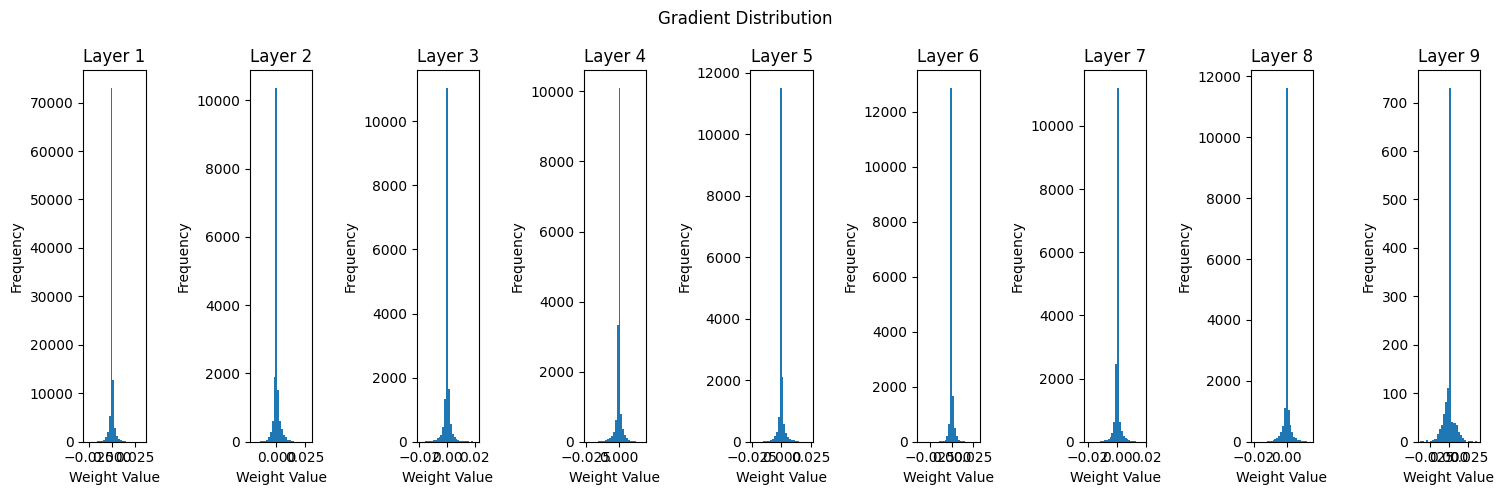

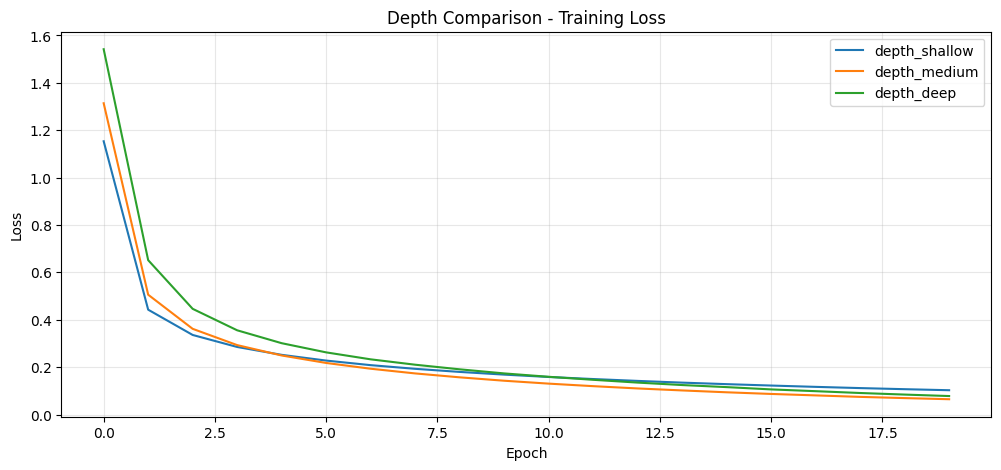

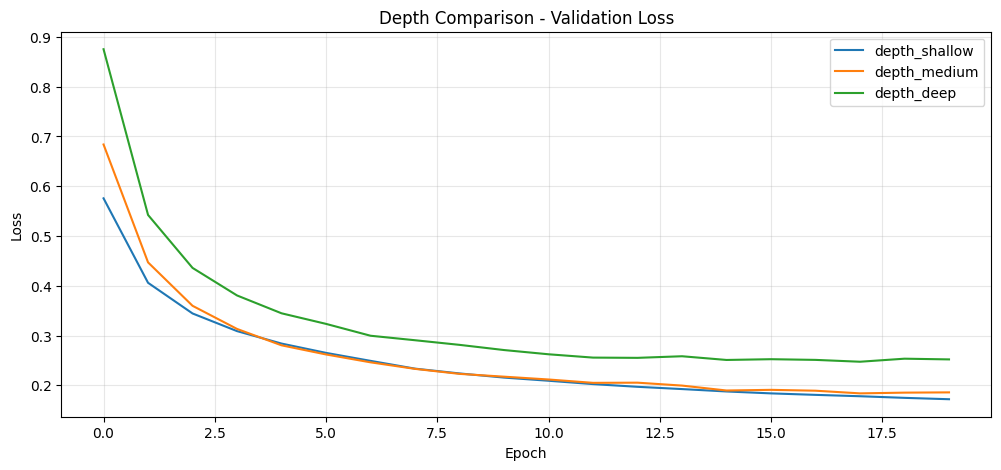

In [16]:
# Depth
depth_variations = [
    {'name': 'shallow', 'n_layers': 1},
    {'name': 'medium', 'n_layers': 4},
    {'name': 'deep', 'n_layers': 8}
]

fixed_width = 128

print("\n--- Depth Experiments ---")
models = {}
histories = {}

for variation in depth_variations:
    n_layers = variation['n_layers']
    name = f"depth_{variation['name']}"
    
    layer_sizes = [784] + [fixed_width] * n_layers + [10]
    activations = ['relu'] * n_layers + ['softmax']
    
    print(f"\nTraining model with depth={n_layers} (hidden layers)")
    model = FFNN(
        layer_sizes=layer_sizes,
        activations=activations,
        loss='categorical_cross_entropy',
        weight_initializer='he',
        # use_rms_norm=True
    )
    
    history = model.fit(
        X_train, 
        y_train_one_hot,
        batch_size=batch_size,
        learning_rate=learning_rate,
        epochs=epochs,
        verbose=1,
        validation_data=(X_test, y_test_one_hot),
        gradient_clip=1.0,
        # learning_rate_decay=0.98,
        learning_rate_decay=1,
        early_stopping_patience=10
    )
    
    models[name] = model
    histories[name] = history
    
    # Evaluate model
    print(f"\nEvaluation for {name}:")
    evaluate_model(model, X_test, y_test, y_test_one_hot)

    has_nan_weights = any(np.isnan(w).any() for w in model.weights)
    has_nan_gradients = any(np.isnan(g).any() for g in model.weight_gradients)
    
    # Plot weight distribution
    print(f"\nWeight distribution for {name}:")
    if has_nan_weights:
        print("cannot plot weight distribution due to nan values")
    else:
        model.plot_weight()
    
    # Plot gradient distribution
    print(f"\nGradient distribution for {name}:")
    if has_nan_gradients:
        print("cannot plot gradient distribution due to nan values")
    else:
        model.plot_gradient_distribution()

plot_comparison({k: v for k, v in histories.items() if k.startswith("depth_")}, 
               "Depth Comparison - Training Loss", "train_loss")
plot_comparison({k: v for k, v in histories.items() if k.startswith("depth_")}, 
               "Depth Comparison - Validation Loss", "val_loss")

## Activation Functions


--- Activation Function Experiments ---

Training model with activation=sigmoid


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 235.78it/s]


Epoch 1/20 - 2.81s - loss: 0.2080 - val_loss: 0.1306 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 231.26it/s]


Epoch 2/20 - 2.82s - loss: 0.1055 - val_loss: 0.0896 - lr: 0.010000


...

Epoch 18/20 - 2.62s - loss: 0.0375 - val_loss: 0.0428 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 245.86it/s]


Epoch 19/20 - 2.67s - loss: 0.0367 - val_loss: 0.0423 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 243.38it/s]


Epoch 20/20 - 2.70s - loss: 0.0359 - val_loss: 0.0416 - lr: 0.010000

Evaluation for activation_sigmoid:
Test accuracy: 0.9269


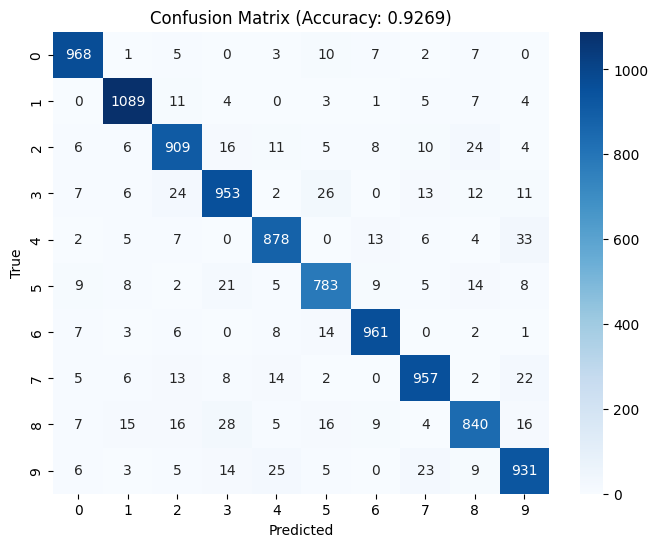


Weight distribution for activation_sigmoid:


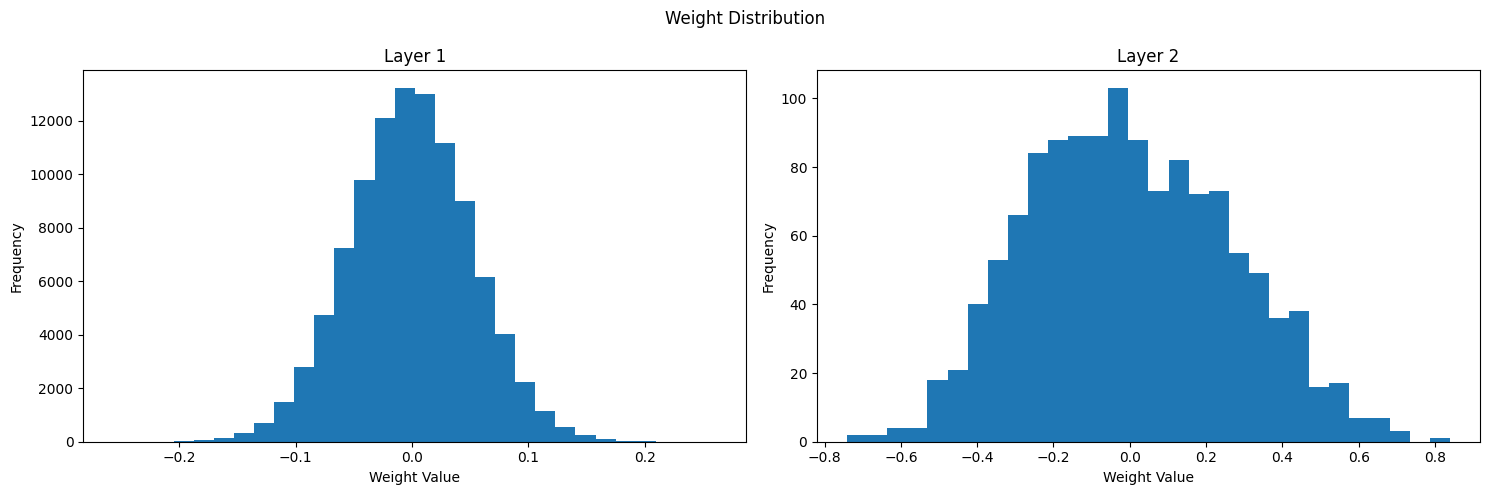


Gradient distribution for activation_sigmoid:


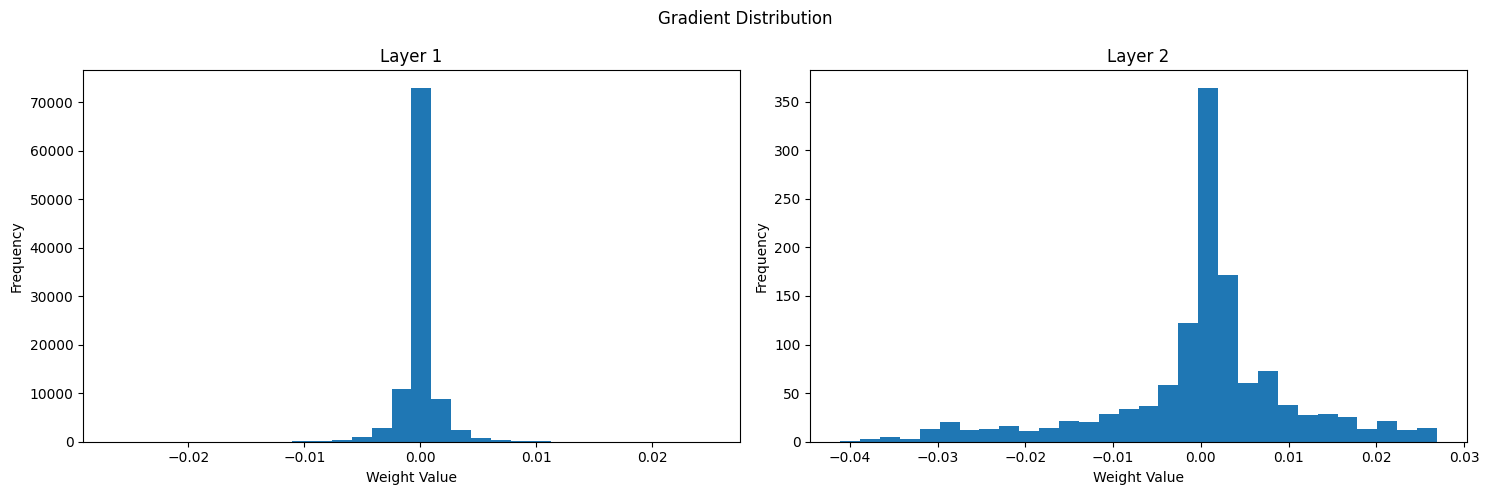


Training model with activation=relu


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 288.68it/s]


Epoch 1/20 - 2.21s - loss: 1.0956 - val_loss: 0.5657 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 287.62it/s]


Epoch 2/20 - 2.22s - loss: 0.4353 - val_loss: 0.3955 - lr: 0.010000


...

Epoch 18/20 - 2.29s - loss: 0.1036 - val_loss: 0.1780 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 283.58it/s]


Epoch 19/20 - 2.25s - loss: 0.0992 - val_loss: 0.1748 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 286.04it/s]


Epoch 20/20 - 2.24s - loss: 0.0950 - val_loss: 0.1721 - lr: 0.010000

Evaluation for activation_relu:
Test accuracy: 0.9551


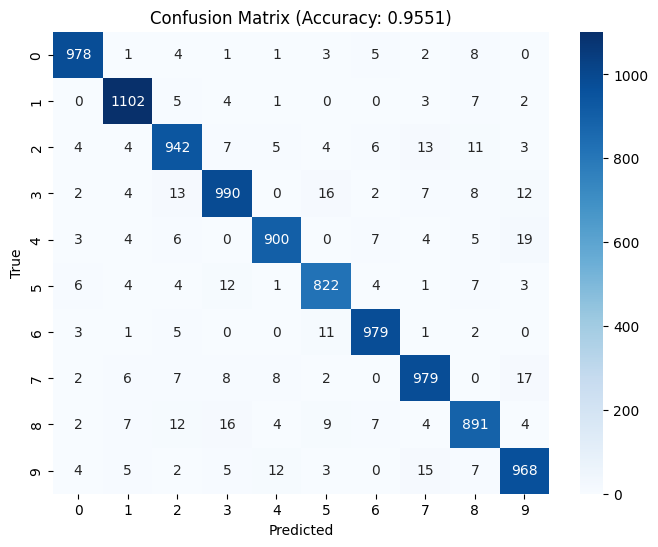


Weight distribution for activation_relu:


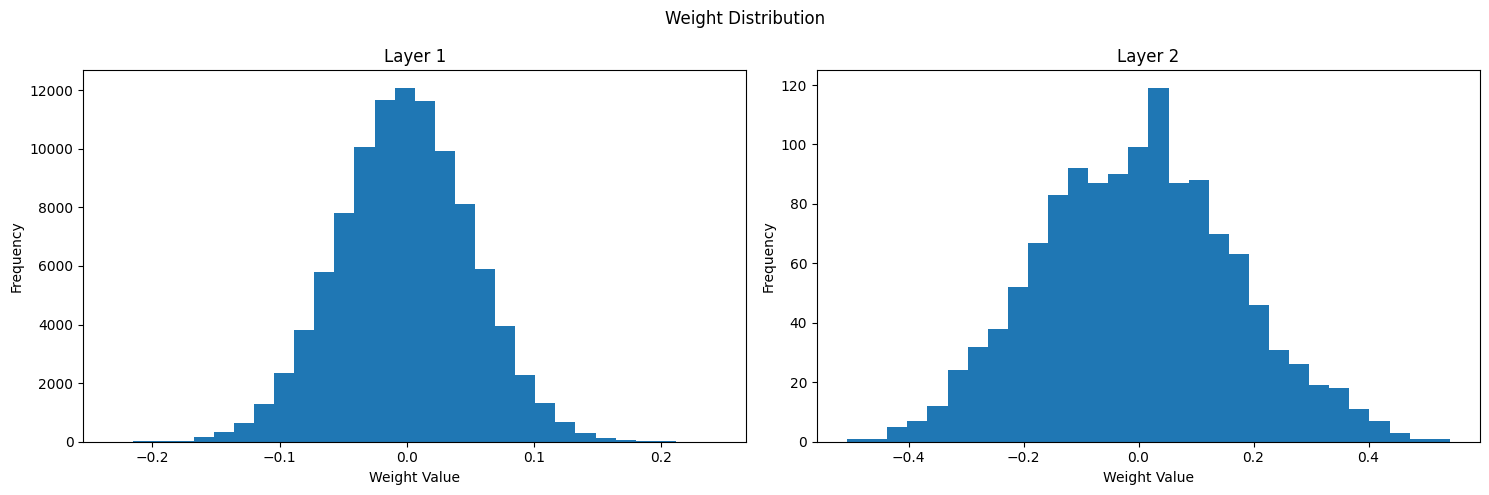


Gradient distribution for activation_relu:


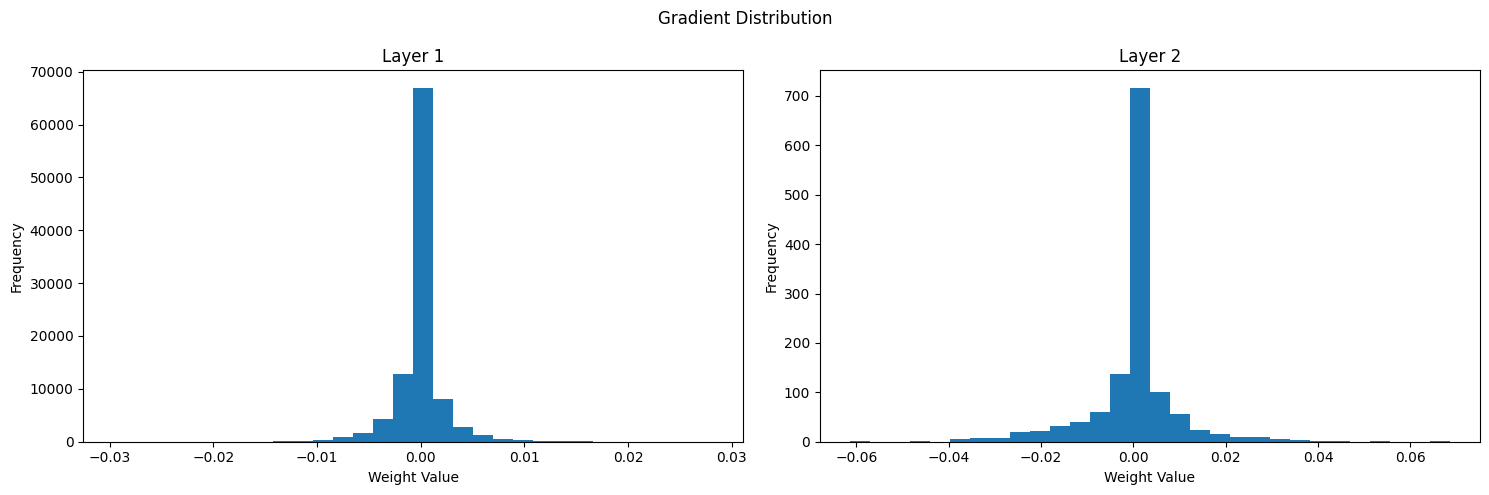


Training model with activation=linear


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 278.89it/s]


Epoch 1/20 - 2.29s - loss: 1.0502 - val_loss: 0.5472 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 277.53it/s]


Epoch 2/20 - 2.30s - loss: 0.4524 - val_loss: 0.4349 - lr: 0.010000


...

Epoch 18/20 - 2.26s - loss: 0.2610 - val_loss: 0.3233 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 283.45it/s]


Epoch 19/20 - 2.25s - loss: 0.2594 - val_loss: 0.3215 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 275.33it/s]


Epoch 20/20 - 2.32s - loss: 0.2579 - val_loss: 0.3221 - lr: 0.010000

Evaluation for activation_linear:
Test accuracy: 0.9166


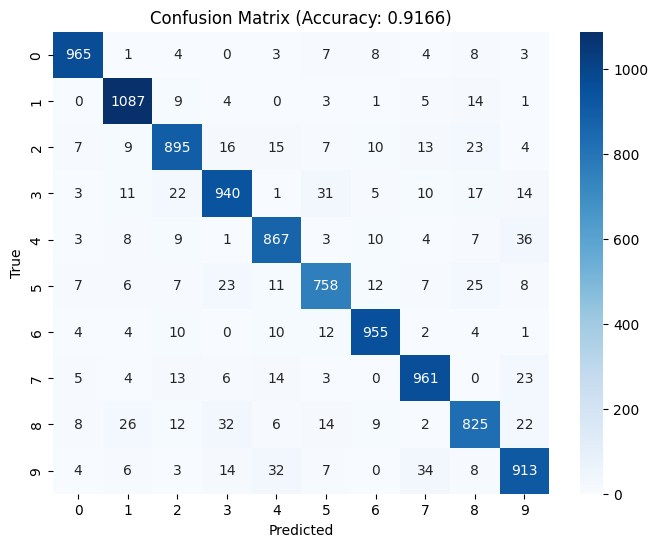


Weight distribution for activation_linear:


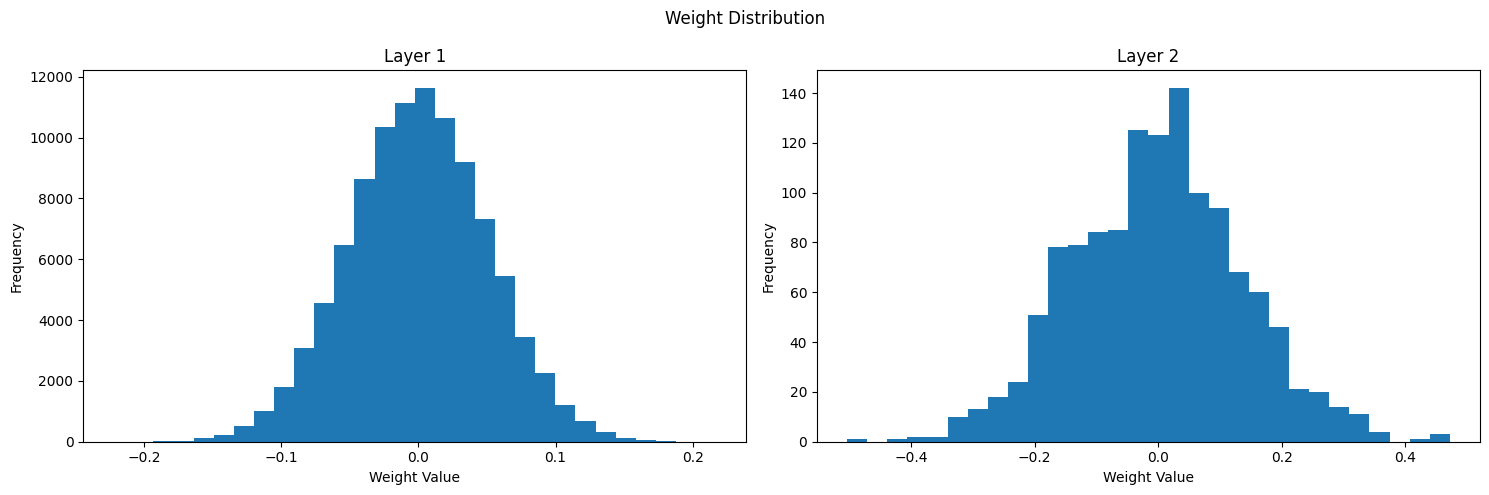


Gradient distribution for activation_linear:


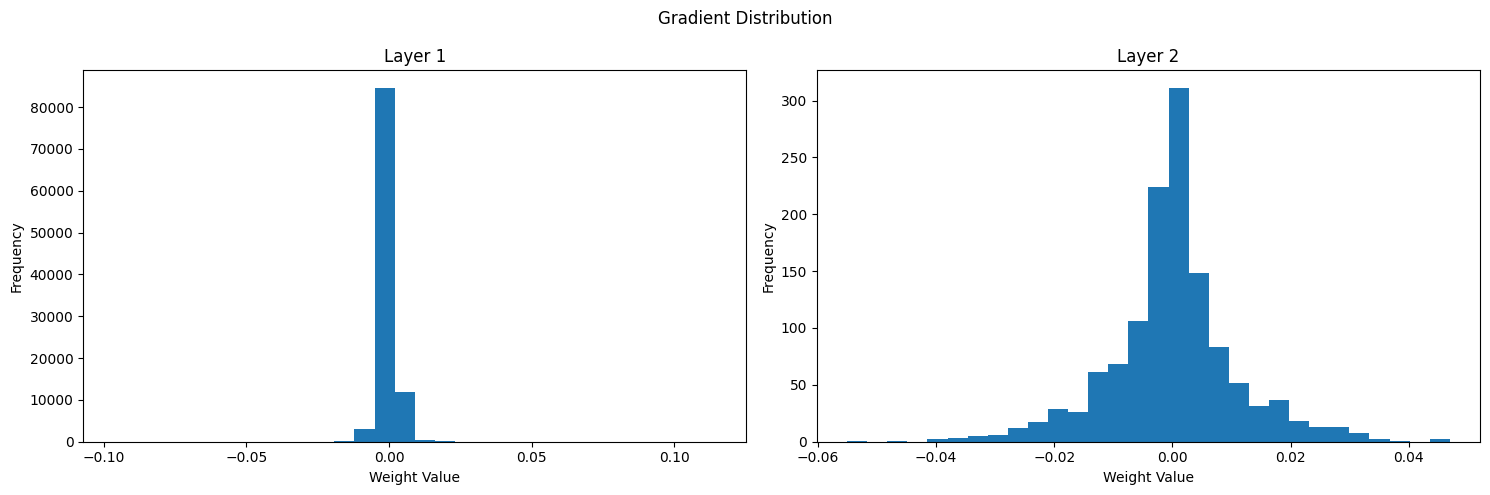


Training model with activation=tanh


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 240.70it/s]


Epoch 1/20 - 2.66s - loss: 0.9495 - val_loss: 0.5056 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 259.12it/s]


Epoch 2/20 - 2.47s - loss: 0.4263 - val_loss: 0.3858 - lr: 0.010000


...

Epoch 18/20 - 2.22s - loss: 0.1586 - val_loss: 0.2128 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 286.96it/s]


Epoch 19/20 - 2.23s - loss: 0.1536 - val_loss: 0.2098 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 290.97it/s]


Epoch 20/20 - 2.20s - loss: 0.1488 - val_loss: 0.2068 - lr: 0.010000

Evaluation for activation_tanh:
Test accuracy: 0.9368


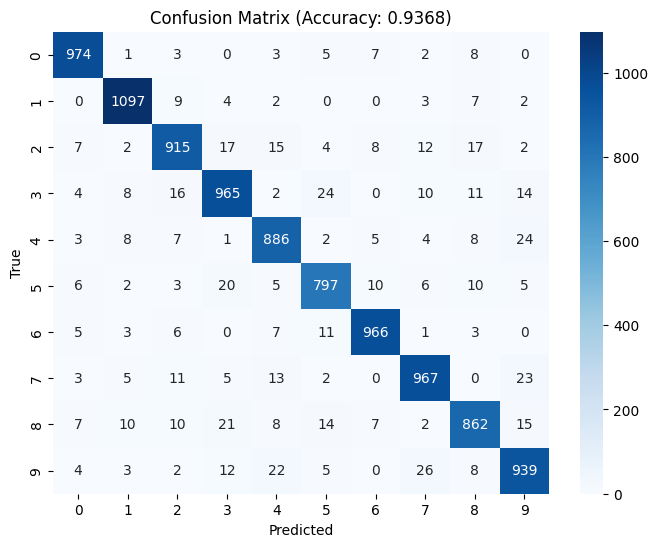


Weight distribution for activation_tanh:


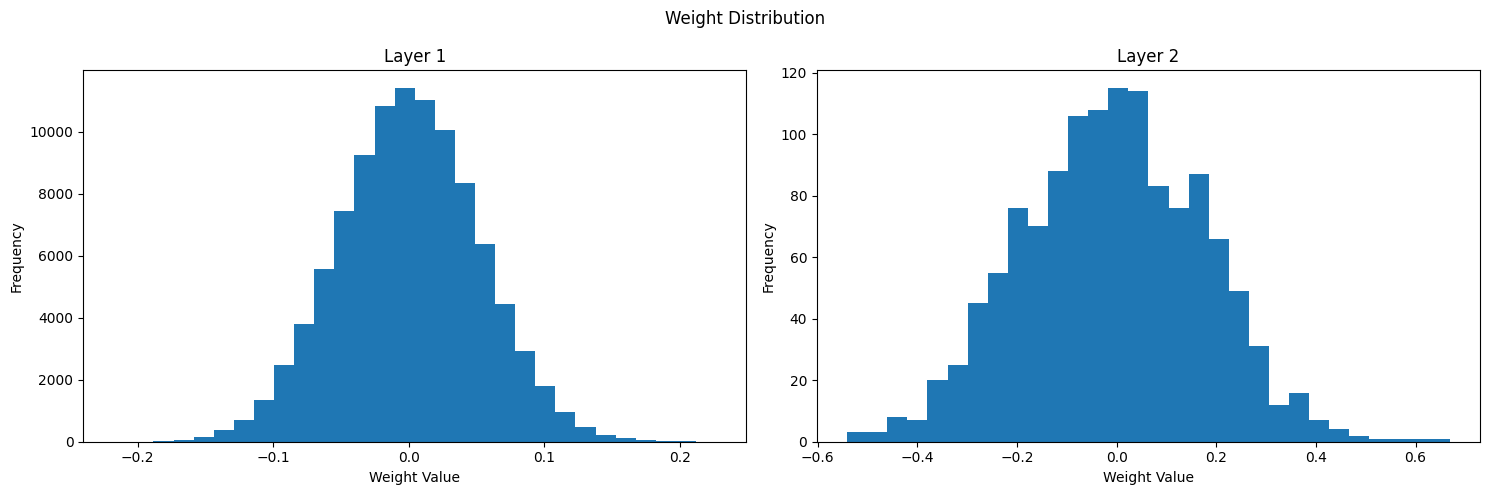


Gradient distribution for activation_tanh:


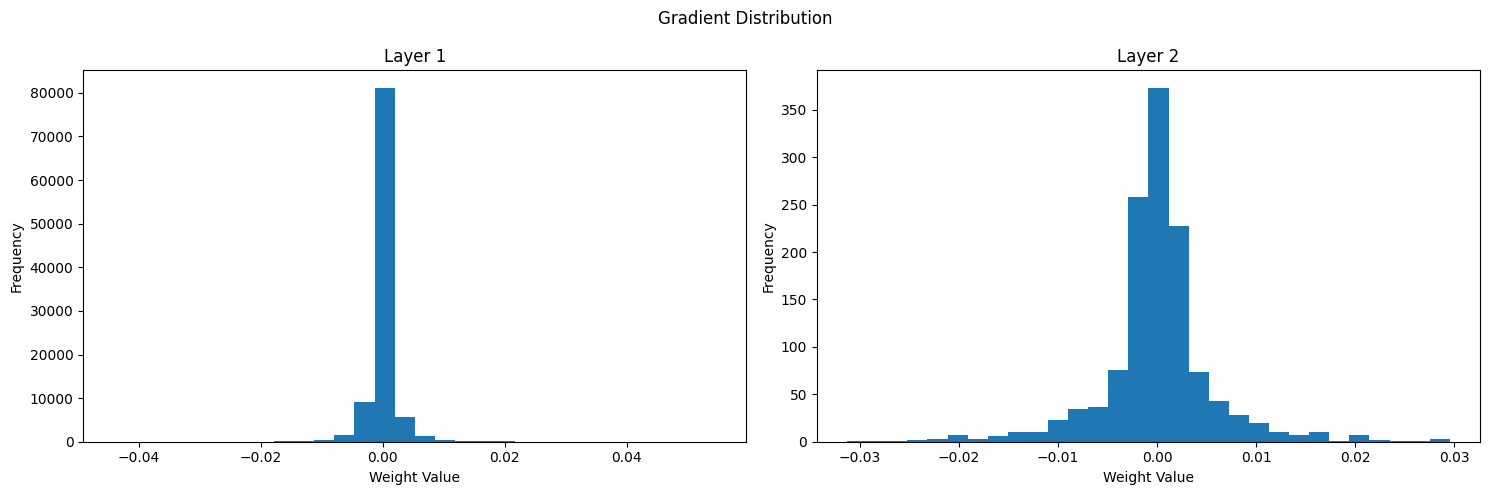

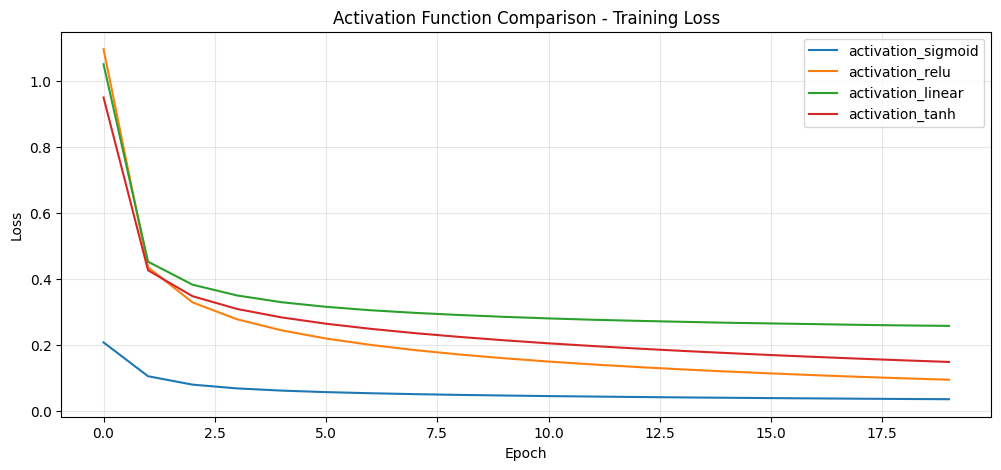

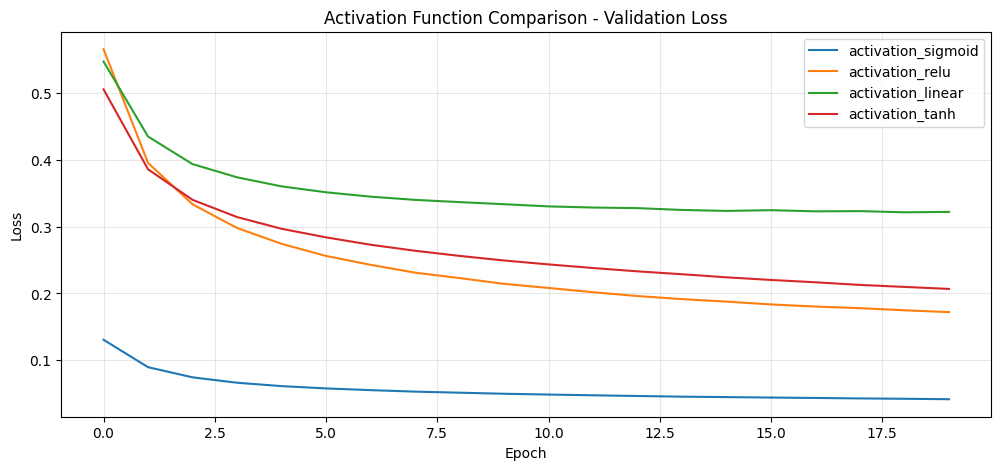

In [22]:
activation_functions = ['sigmoid', 'relu', 'linear', 'tanh']

fixed_width = 128
fixed_layer_sizes = [784, fixed_width, 10]

activation_models = {}
activation_histories = {}

print("\n--- Activation Function Experiments ---")
for activation in activation_functions:
    name = f"activation_{activation}"
    
    print(f"\nTraining model with activation={activation}")
    if activation == "sigmoid":
        model = FFNN(
        layer_sizes=fixed_layer_sizes,
        activations=[activation, 'softmax'],
        loss='binary_cross_entropy',
        weight_initializer='he',
        # use_rms_norm=True
    )
    else:
        model = FFNN(
        layer_sizes=fixed_layer_sizes,
        activations=[activation, 'softmax'],
        loss='categorical_cross_entropy',
        weight_initializer='he',
        # use_rms_norm=True
    )
    
    
    # Use the new fit method instead of manual training loop
    history = model.fit(
        X_train, 
        y_train_one_hot,
        batch_size=batch_size,
        learning_rate=learning_rate,
        epochs=epochs,
        verbose=1,
        validation_data=(X_test, y_test_one_hot),
        gradient_clip=1.0,
        learning_rate_decay=1,
        early_stopping_patience=5 
    )
    
    activation_models[name] = model
    activation_histories[name] = history
    
    # Evaluate model
    print(f"\nEvaluation for {name}:")
    evaluate_model(model, X_test, y_test, y_test_one_hot)

    has_nan_weights = any(np.isnan(w).any() for w in model.weights)
    has_nan_gradients = any(np.isnan(g).any() for g in model.weight_gradients)
    
    # Plot weight distribution
    print(f"\nWeight distribution for {name}:")
    if has_nan_weights:
        print("can't plot weight distribution due to nan values")
    else:
        model.plot_weight()
    
    # Plot gradient distribution
    print(f"\nGradient distribution for {name}:")
    if has_nan_gradients:
        print("can't plot gradient distribution due to nan values")
    else:
        model.plot_gradient_distribution()

plot_comparison(activation_histories, "Activation Function Comparison - Training Loss", "train_loss")
plot_comparison(activation_histories, "Activation Function Comparison - Validation Loss", "val_loss")

## Learning Rate


--- Learning Rate Experiments ---

Training model with learning_rate=0.001


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 273.58it/s]


Epoch 1/20 - 2.33s - loss: 2.3276 - val_loss: 1.9693 - lr: 0.001000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 280.65it/s]


Epoch 2/20 - 2.29s - loss: 1.6893 - val_loss: 1.4939 - lr: 0.001000


...

Epoch 18/20 - 2.25s - loss: 0.3774 - val_loss: 0.4172 - lr: 0.001000


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 286.43it/s]


Epoch 19/20 - 2.23s - loss: 0.3662 - val_loss: 0.4070 - lr: 0.001000


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 287.22it/s]


Epoch 20/20 - 2.23s - loss: 0.3559 - val_loss: 0.3978 - lr: 0.001000

Evaluation for lr_0.001:
Test accuracy: 0.8925


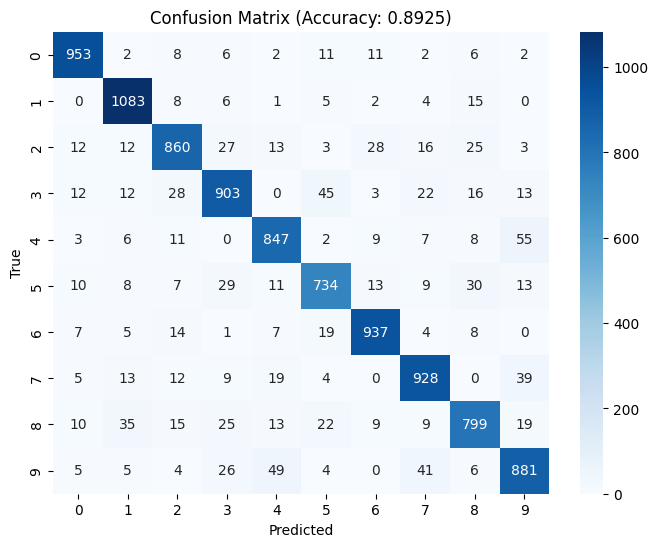


Weight distribution for lr_0.001:


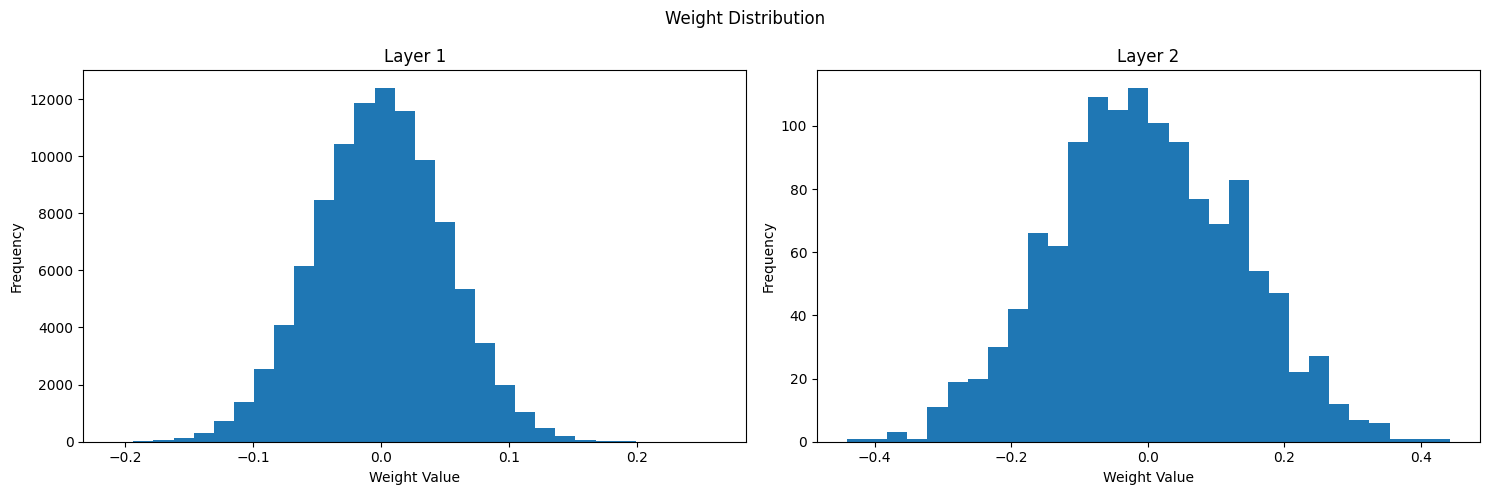


Gradient distribution for lr_0.001:


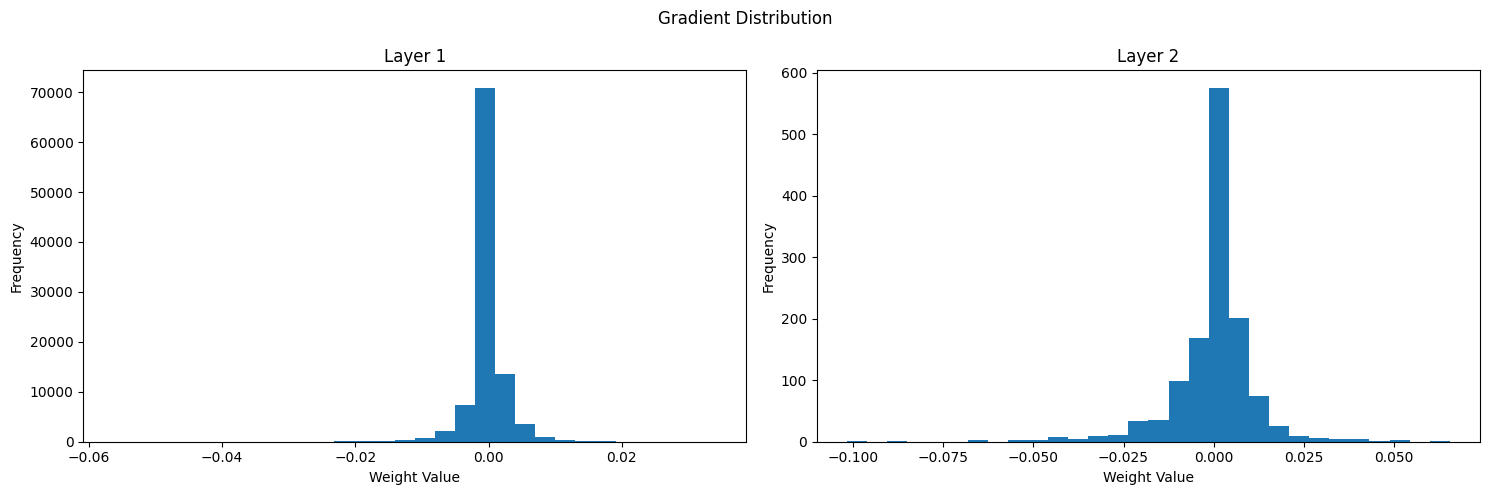


Training model with learning_rate=0.01


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 291.51it/s]


Epoch 1/20 - 2.19s - loss: 1.1032 - val_loss: 0.5576 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 288.02it/s]


Epoch 2/20 - 2.22s - loss: 0.4324 - val_loss: 0.3845 - lr: 0.010000


...

Epoch 18/20 - 2.29s - loss: 0.1054 - val_loss: 0.1770 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 284.24it/s]


Epoch 19/20 - 2.25s - loss: 0.1009 - val_loss: 0.1746 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 279.39it/s]


Epoch 20/20 - 2.29s - loss: 0.0968 - val_loss: 0.1725 - lr: 0.010000

Evaluation for lr_0.01:
Test accuracy: 0.9535


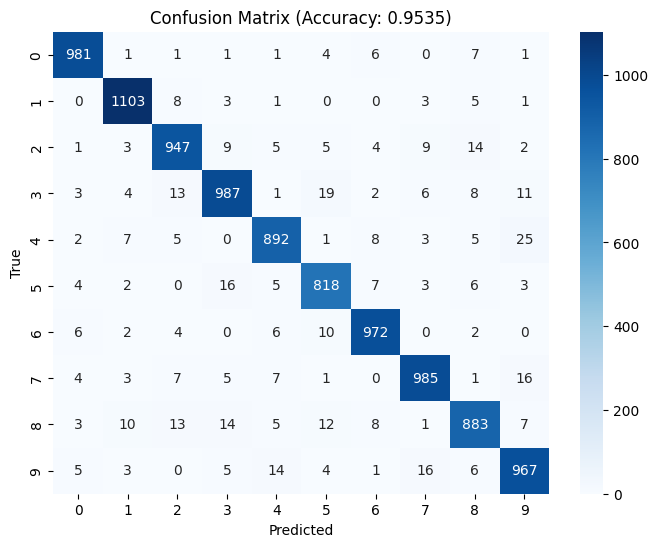


Weight distribution for lr_0.01:


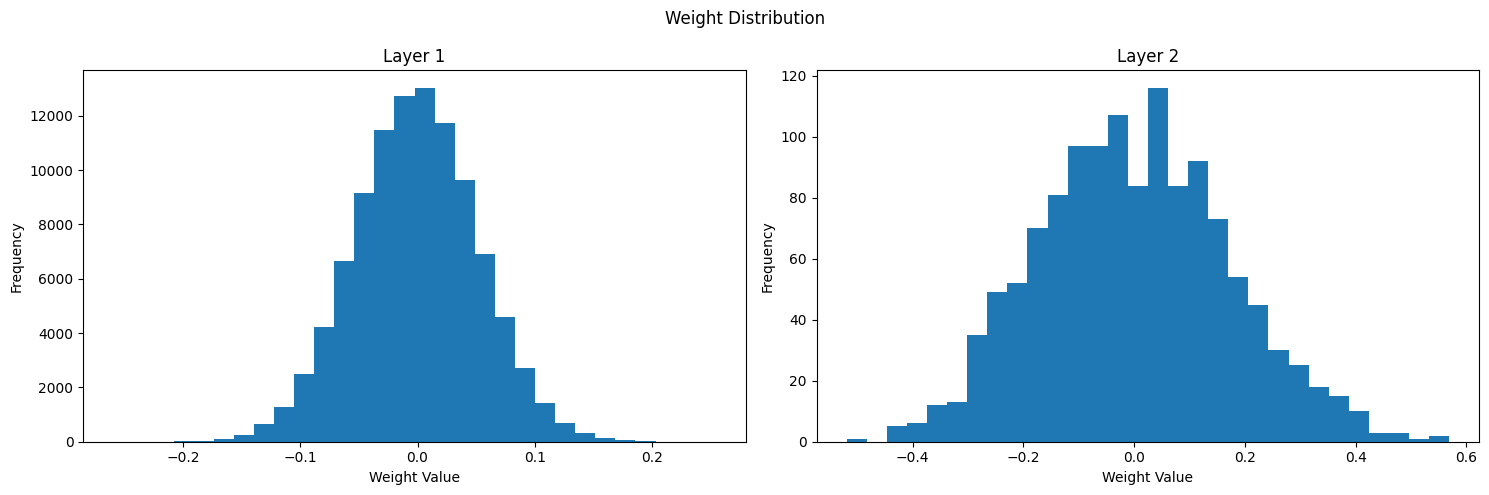


Gradient distribution for lr_0.01:


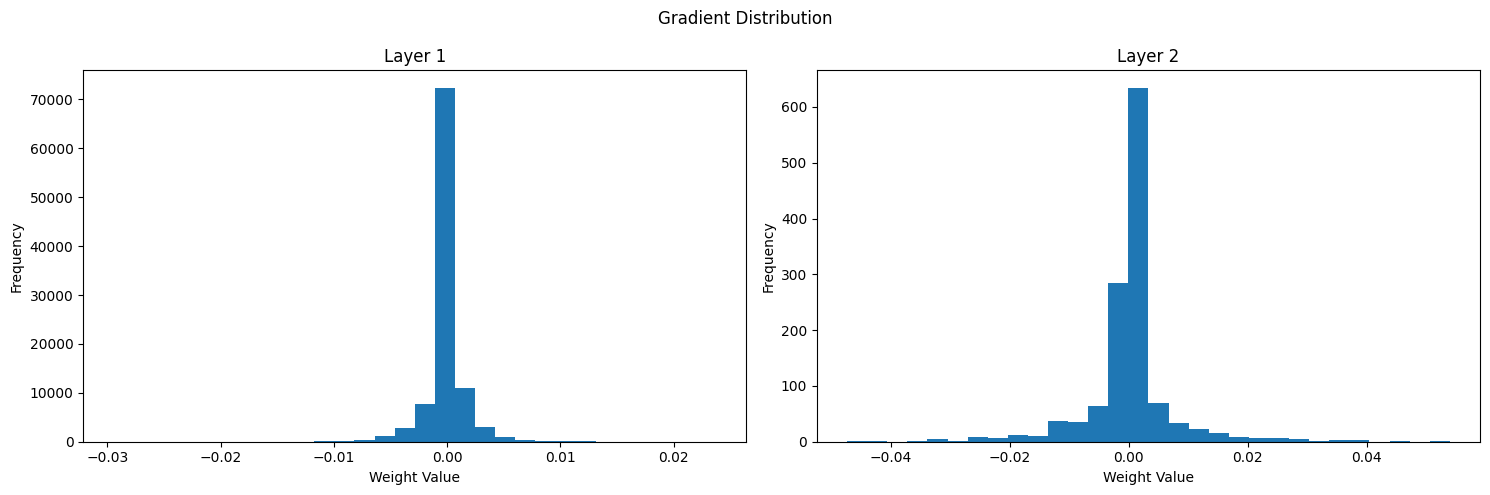


Training model with learning_rate=0.1


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 278.40it/s]


Epoch 1/20 - 2.30s - loss: 0.3972 - val_loss: 0.2321 - lr: 0.100000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 272.21it/s]


Epoch 2/20 - 2.35s - loss: 0.1658 - val_loss: 0.1804 - lr: 0.100000


...

Epoch 18/20 - 2.18s - loss: 0.0068 - val_loss: 0.1432 - lr: 0.100000


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 293.91it/s]


Epoch 19/20 - 2.18s - loss: 0.0063 - val_loss: 0.1441 - lr: 0.100000


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 297.19it/s]


Epoch 20/20 - 2.15s - loss: 0.0059 - val_loss: 0.1453 - lr: 0.100000

Evaluation for lr_0.1:
Test accuracy: 0.9679


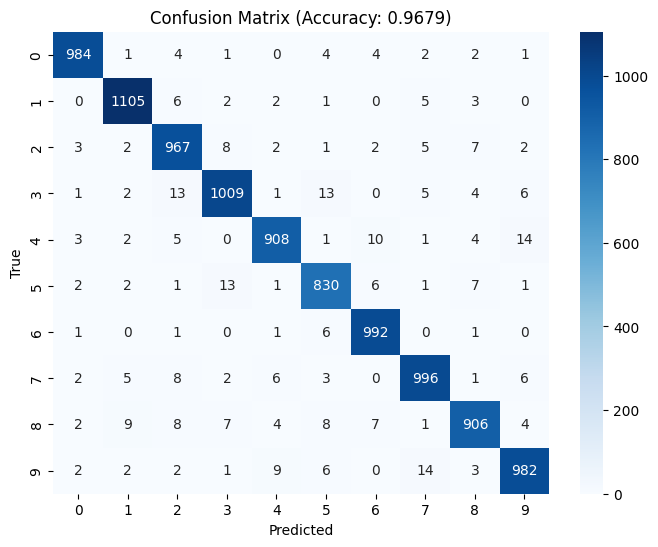


Weight distribution for lr_0.1:


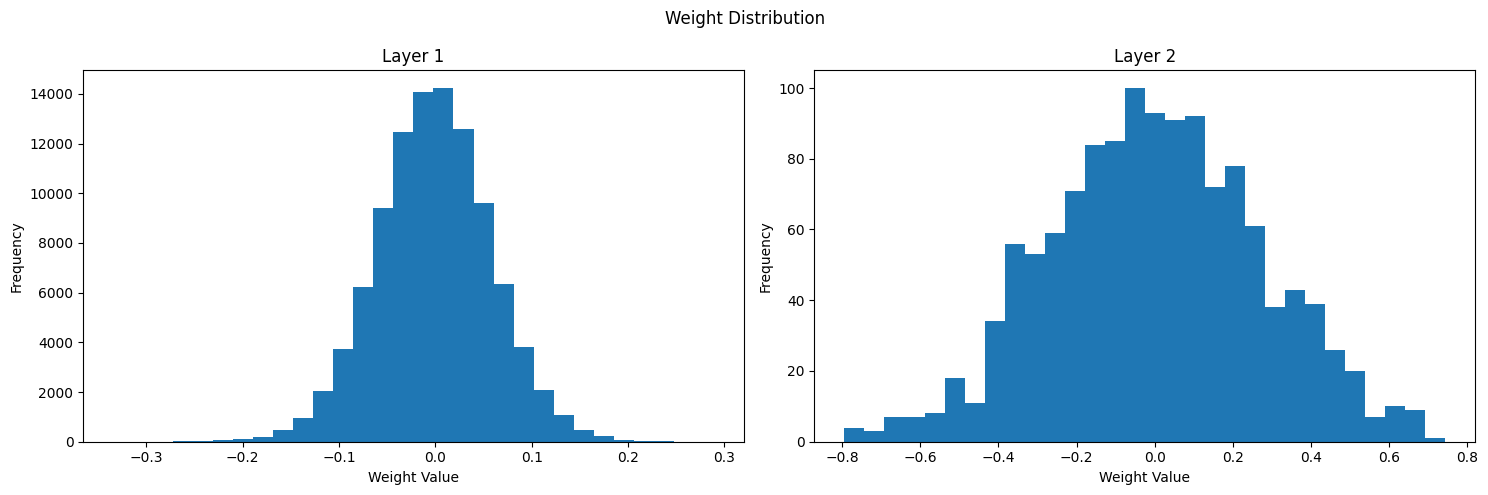


Gradient distribution for lr_0.1:


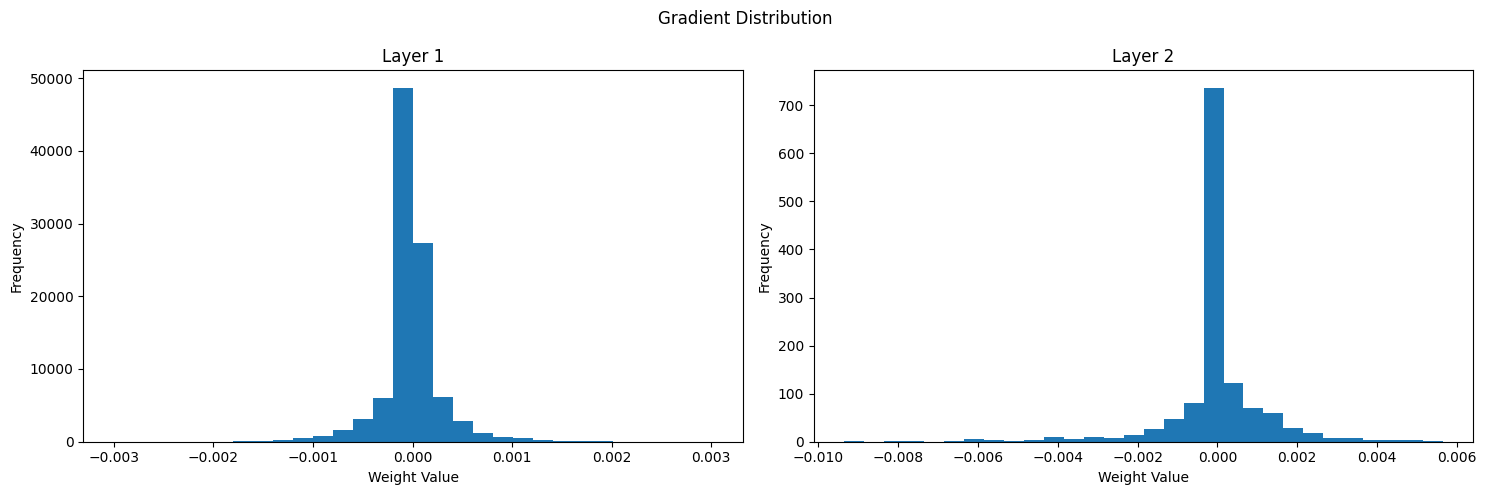

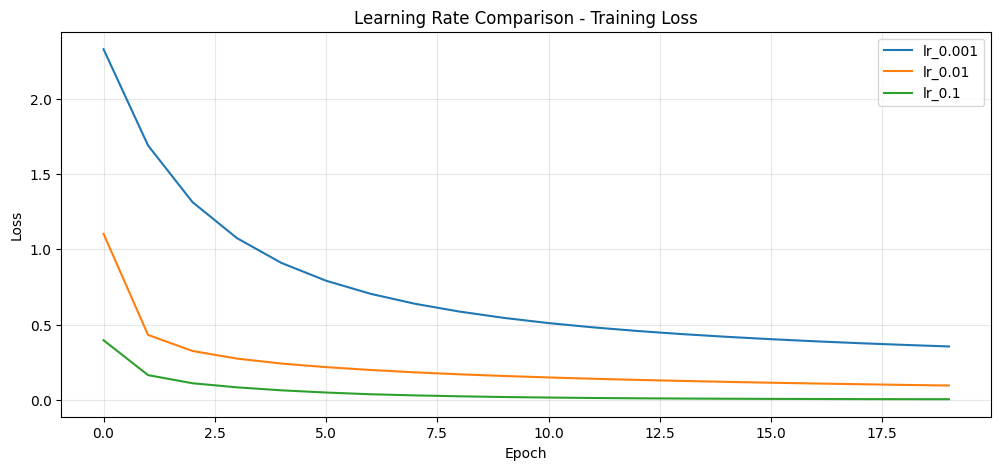

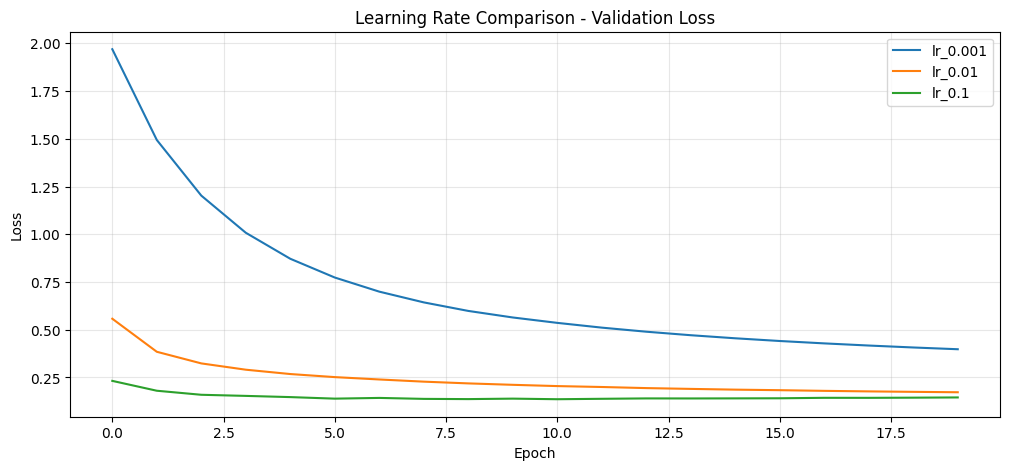

In [24]:
# Different Learning Rates
learning_rates = [0.001, 0.01, 0.1]

fixed_width = 128
fixed_layer_sizes = [784, fixed_width, 10]

lr_models = {}
lr_histories = {}

print("\n--- Learning Rate Experiments ---")
for lr in learning_rates:
    name = f"lr_{lr}"
    
    print(f"\nTraining model with learning_rate={lr}")
    model = FFNN(
        layer_sizes=fixed_layer_sizes,
        activations=['relu', 'softmax'],
        loss='categorical_cross_entropy',
        weight_initializer='he',
        # use_rms_norm=True
    )
    
    # Decay disabled, karena ngetes learning rate
    history = model.fit(
        X_train, 
        y_train_one_hot,
        batch_size=batch_size,
        learning_rate=lr,
        epochs=epochs,
        verbose=1,
        validation_data=(X_test, y_test_one_hot),
        gradient_clip=1.0,
        learning_rate_decay=1.0,
        early_stopping_patience=20
    )
    
    lr_models[name] = model
    lr_histories[name] = history
    
    # Evaluate model
    print(f"\nEvaluation for {name}:")
    evaluate_model(model, X_test, y_test, y_test_one_hot)

    has_nan_weights = any(np.isnan(w).any() for w in model.weights)
    has_nan_gradients = any(np.isnan(g).any() for g in model.weight_gradients)
    
    # Plot weight distribution
    print(f"\nWeight distribution for {name}:")
    if has_nan_weights:
        print("can't plot weight distribution due to nan values")
    else:
        model.plot_weight()
    
    # Plot gradient distribution
    print(f"\nGradient distribution for {name}:")
    if has_nan_gradients:
        print("can't plot gradient distribution due to nan values")
    else:
        model.plot_gradient_distribution()

# Plot training histories
plot_comparison(lr_histories, "Learning Rate Comparison - Training Loss", "train_loss")
plot_comparison(lr_histories, "Learning Rate Comparison - Validation Loss", "val_loss")

## Weight Initialization


--- Weight Initialization Experiments ---

Training model with initializer=zero


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 280.68it/s]


Epoch 1/20 - 2.28s - loss: 2.3020 - val_loss: 2.3014 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 288.28it/s]


Epoch 2/20 - 2.22s - loss: 2.3014 - val_loss: 2.3010 - lr: 0.010000


...

Epoch 18/20 - 2.24s - loss: 2.3011 - val_loss: 2.3008 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 285.91it/s]


Epoch 19/20 - 2.23s - loss: 2.3011 - val_loss: 2.3008 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 286.17it/s]


Epoch 20/20 - 2.24s - loss: 2.3011 - val_loss: 2.3008 - lr: 0.010000

Evaluation for init_zero:
Test accuracy: 0.1124


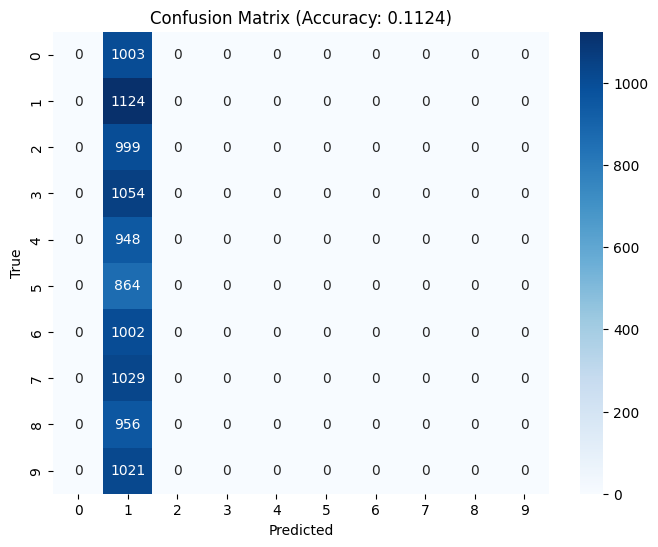


Weight distribution for init_zero:


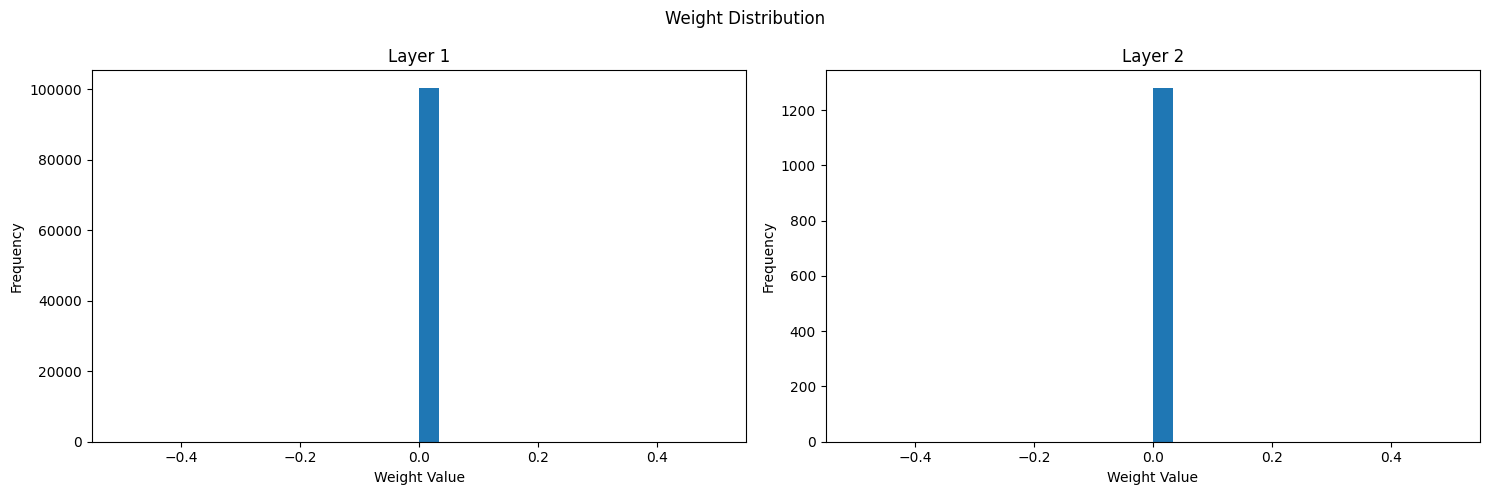


Gradient distribution for init_zero:


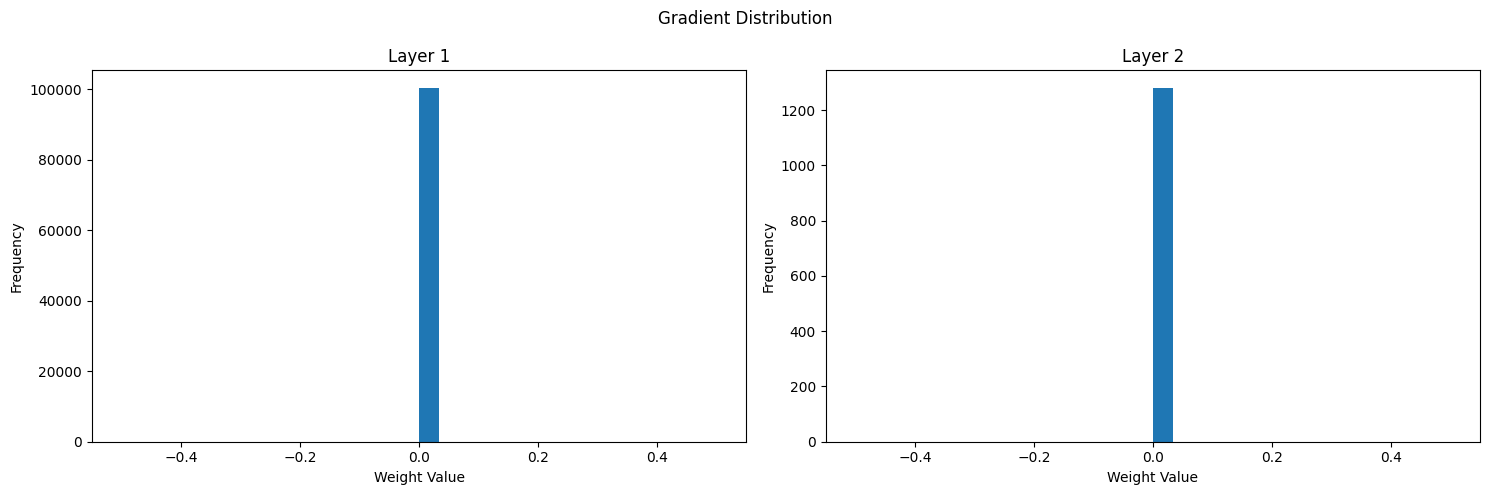


Training model with initializer=uniform


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 285.39it/s]


Epoch 1/20 - 2.24s - loss: 1.1857 - val_loss: 0.5527 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 276.67it/s]


Epoch 2/20 - 2.31s - loss: 0.4249 - val_loss: 0.3715 - lr: 0.010000


...

Epoch 18/20 - 2.19s - loss: 0.1169 - val_loss: 0.1661 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 286.70it/s]


Epoch 19/20 - 2.23s - loss: 0.1122 - val_loss: 0.1635 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 293.43it/s]


Epoch 20/20 - 2.18s - loss: 0.1080 - val_loss: 0.1611 - lr: 0.010000

Evaluation for init_uniform:
Test accuracy: 0.9544


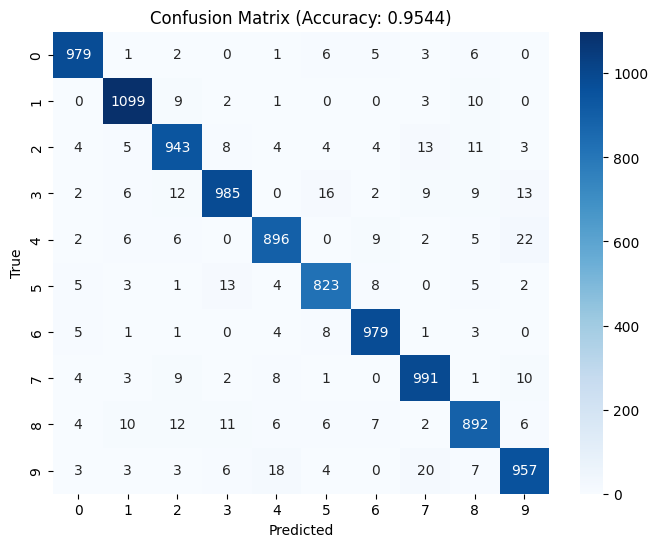


Weight distribution for init_uniform:


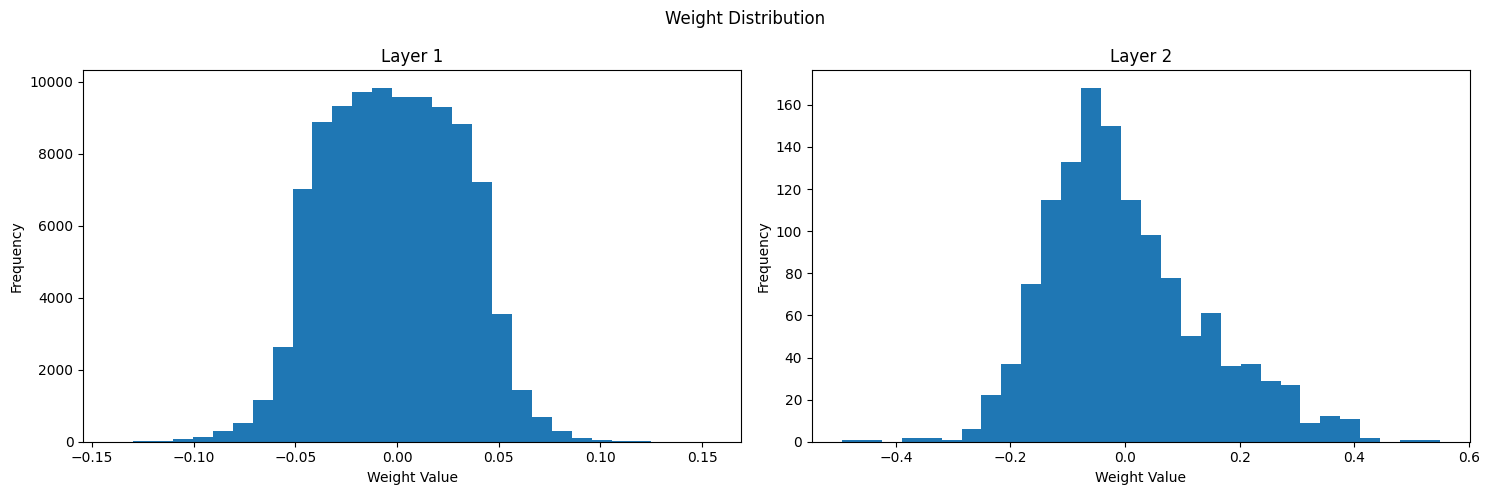


Gradient distribution for init_uniform:


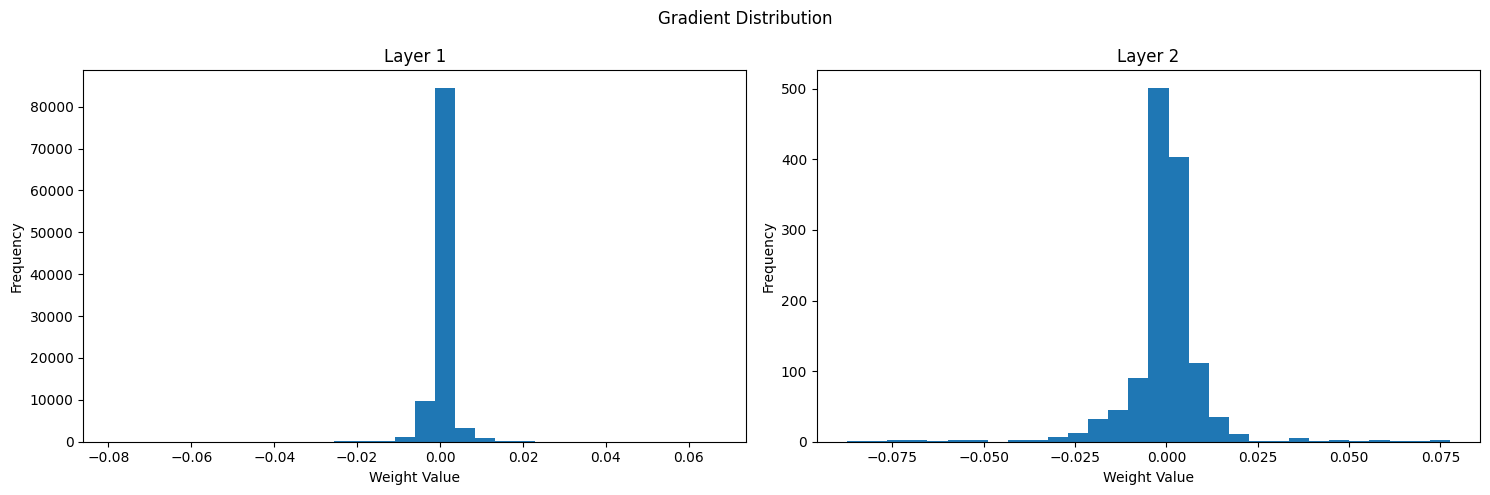


Training model with initializer=normal


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 290.02it/s]


Epoch 1/20 - 2.20s - loss: 1.1416 - val_loss: 0.5863 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 290.02it/s]


Epoch 2/20 - 2.20s - loss: 0.4564 - val_loss: 0.3950 - lr: 0.010000


...

Epoch 18/20 - 2.20s - loss: 0.1219 - val_loss: 0.1744 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 291.72it/s]


Epoch 19/20 - 2.19s - loss: 0.1172 - val_loss: 0.1715 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 295.95it/s]


Epoch 20/20 - 2.16s - loss: 0.1125 - val_loss: 0.1681 - lr: 0.010000

Evaluation for init_normal:
Test accuracy: 0.9523


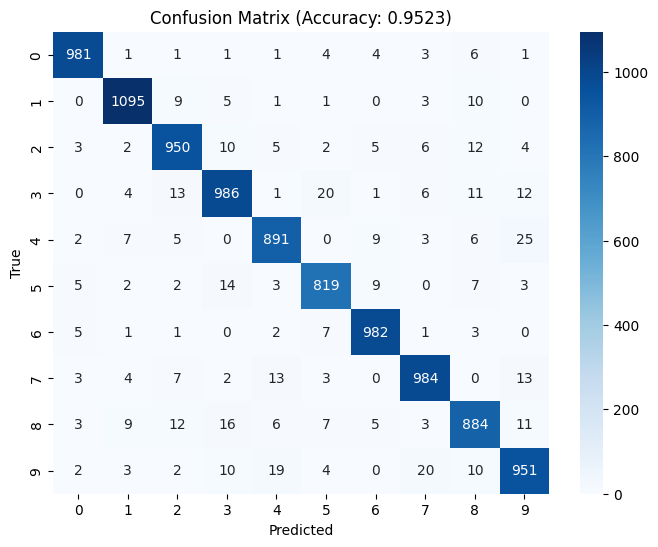


Weight distribution for init_normal:


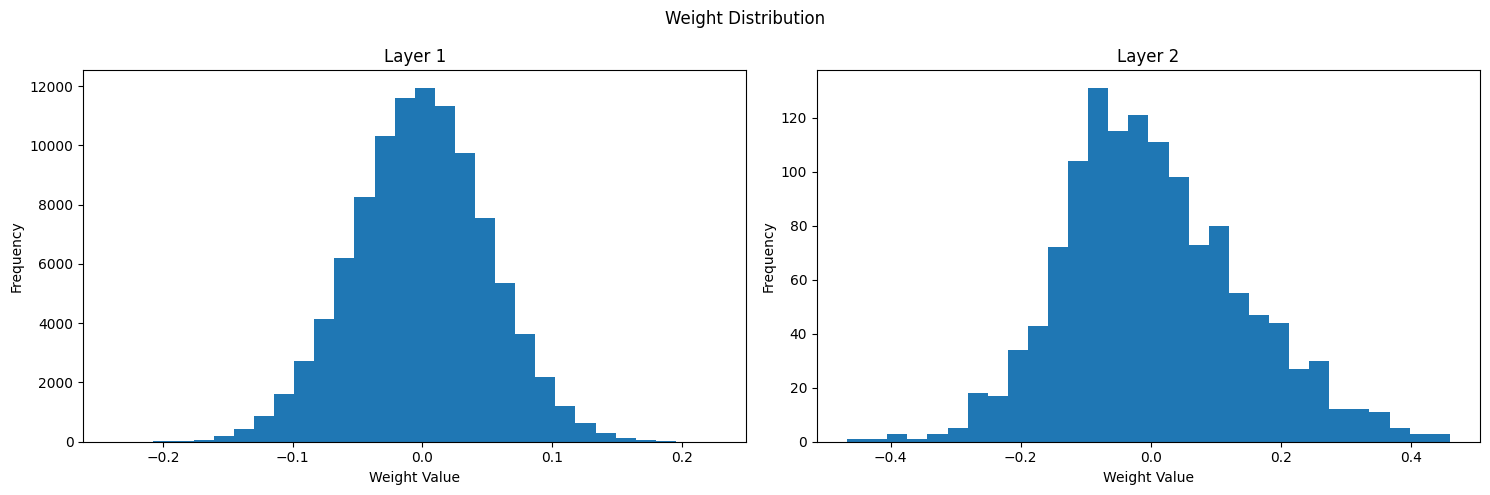


Gradient distribution for init_normal:


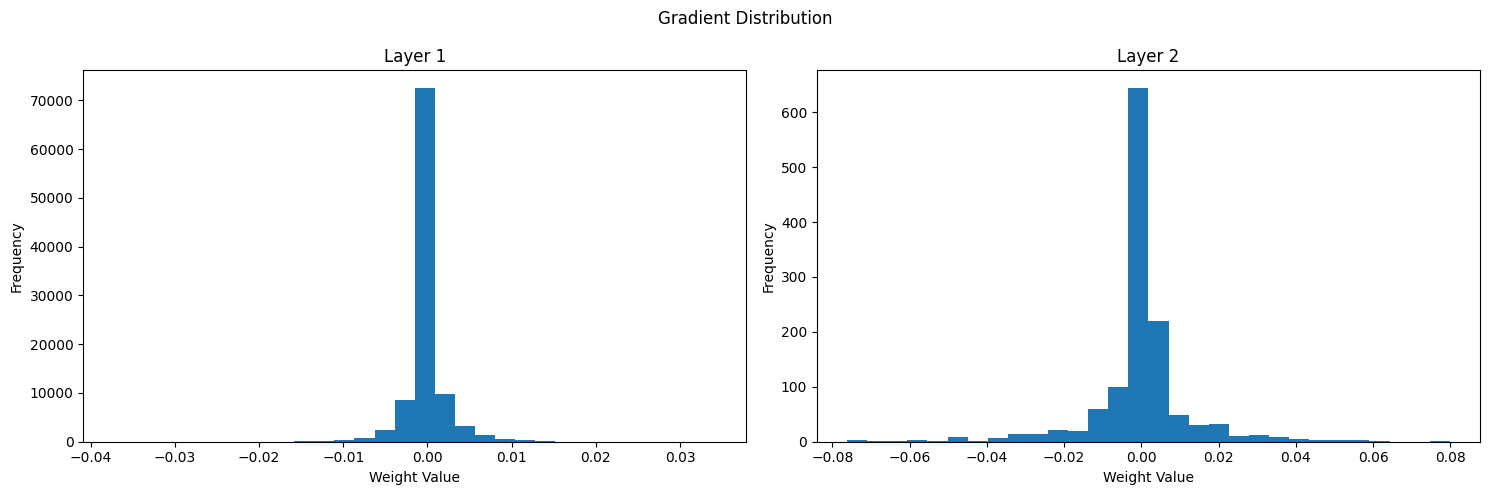


Training model with initializer=xavier


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 289.49it/s]


Epoch 1/20 - 2.21s - loss: 1.0580 - val_loss: 0.5581 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 292.88it/s]


Epoch 2/20 - 2.18s - loss: 0.4239 - val_loss: 0.3914 - lr: 0.010000


...

Epoch 18/20 - 2.23s - loss: 0.1084 - val_loss: 0.1749 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 291.11it/s]


Epoch 19/20 - 2.20s - loss: 0.1039 - val_loss: 0.1724 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 285.52it/s]


Epoch 20/20 - 2.24s - loss: 0.0999 - val_loss: 0.1695 - lr: 0.010000

Evaluation for init_xavier:
Test accuracy: 0.9540


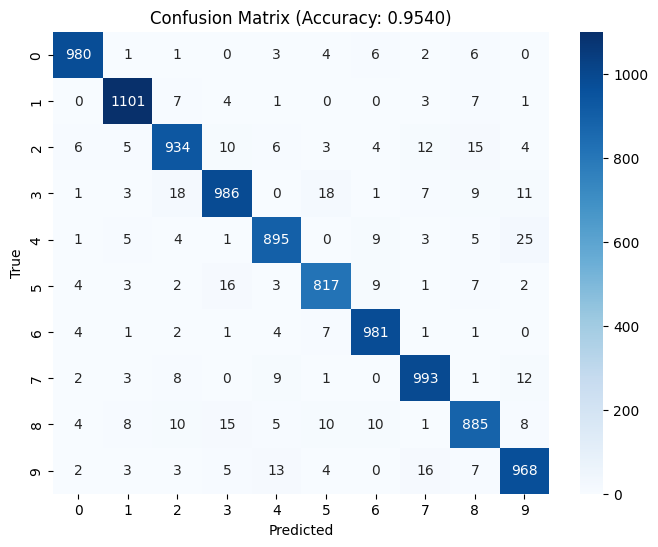


Weight distribution for init_xavier:


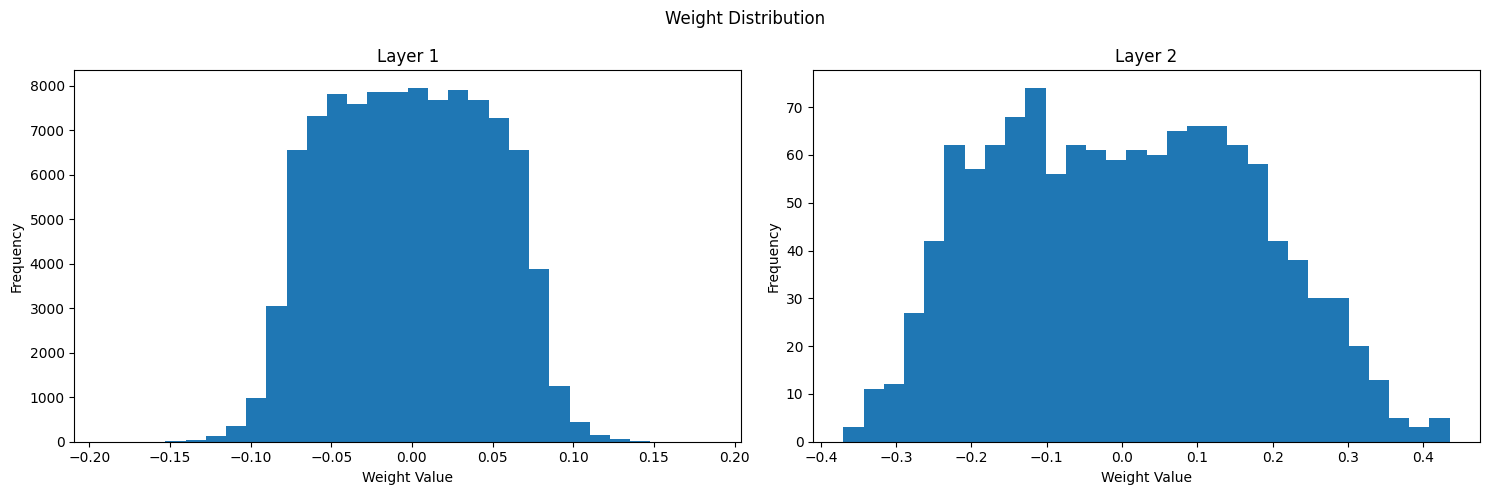


Gradient distribution for init_xavier:


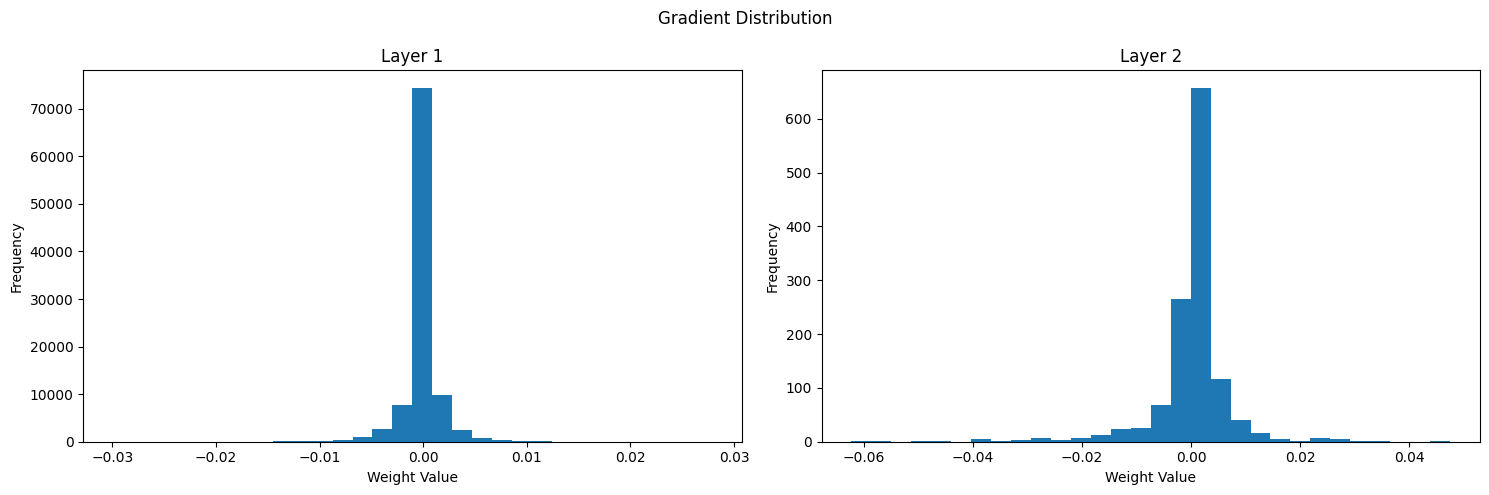


Training model with initializer=he


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 288.42it/s]


Epoch 1/20 - 2.22s - loss: 1.1276 - val_loss: 0.5533 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 294.26it/s]


Epoch 2/20 - 2.17s - loss: 0.4373 - val_loss: 0.3827 - lr: 0.010000


...

Epoch 18/20 - 2.17s - loss: 0.1053 - val_loss: 0.1694 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 293.98it/s]


Epoch 19/20 - 2.17s - loss: 0.1009 - val_loss: 0.1669 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 297.19it/s]


Epoch 20/20 - 2.15s - loss: 0.0969 - val_loss: 0.1642 - lr: 0.010000

Evaluation for init_he:
Test accuracy: 0.9545


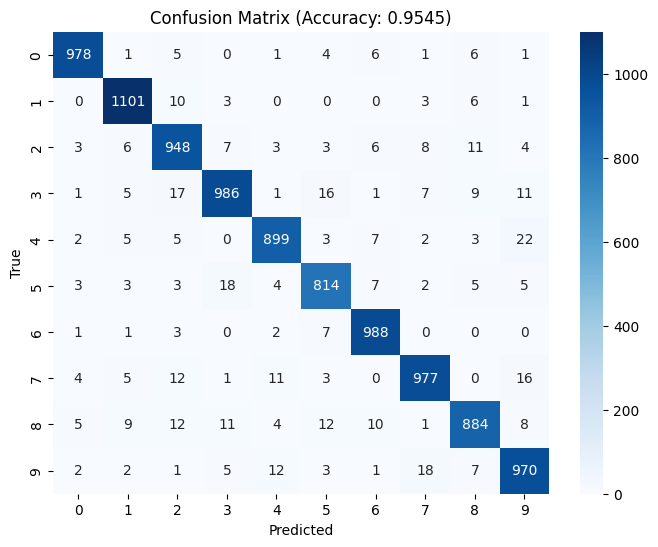


Weight distribution for init_he:


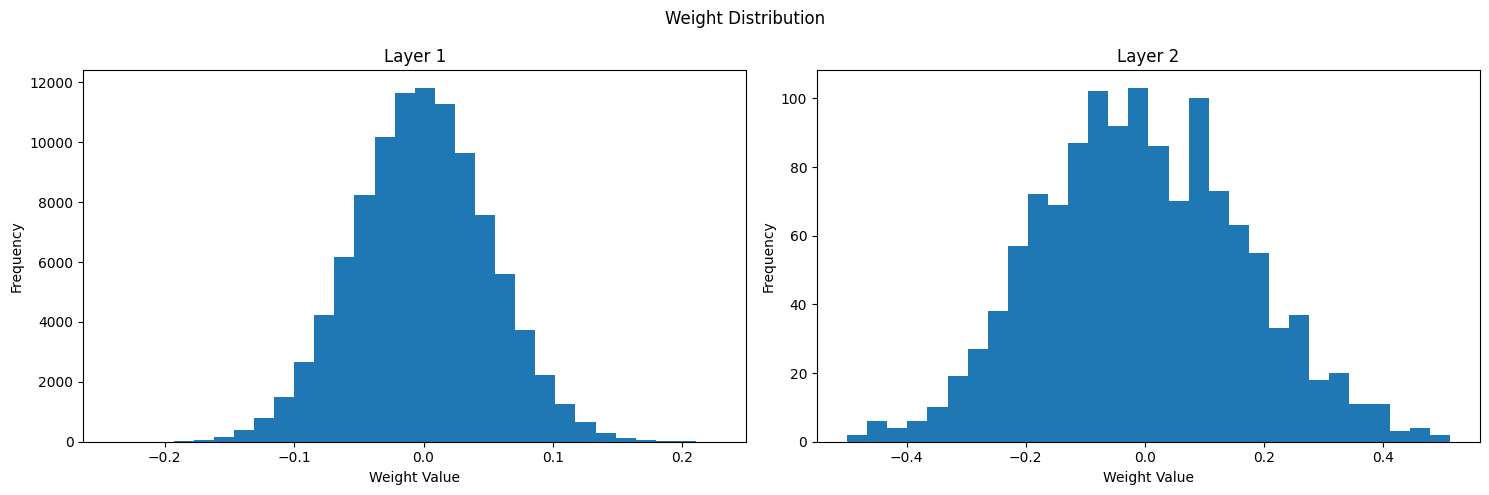


Gradient distribution for init_he:


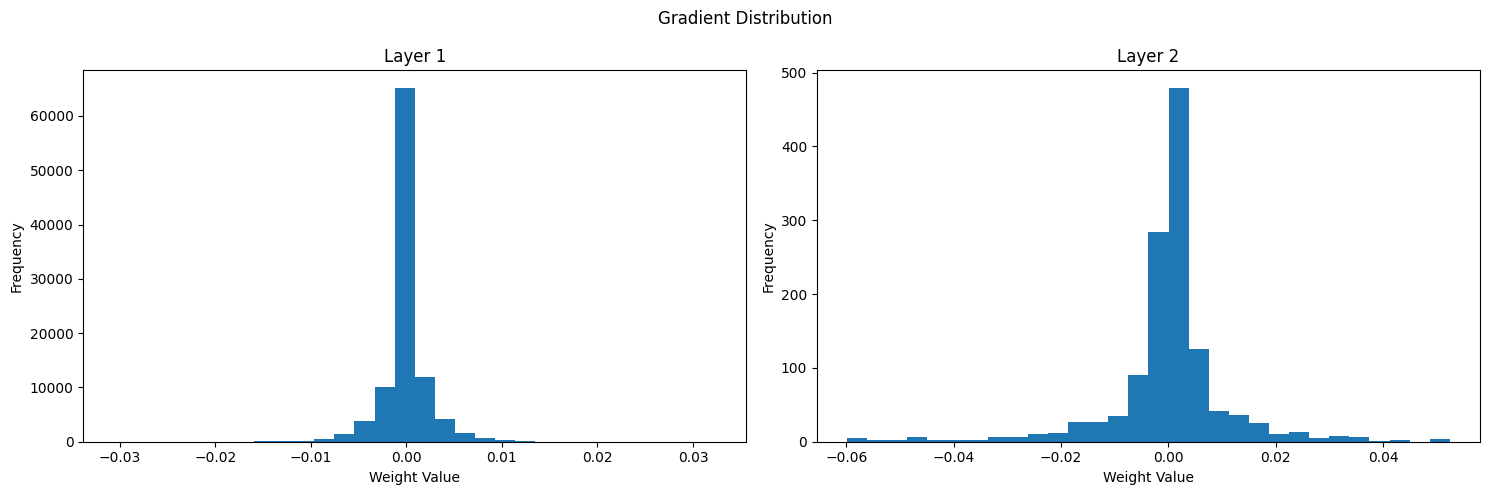

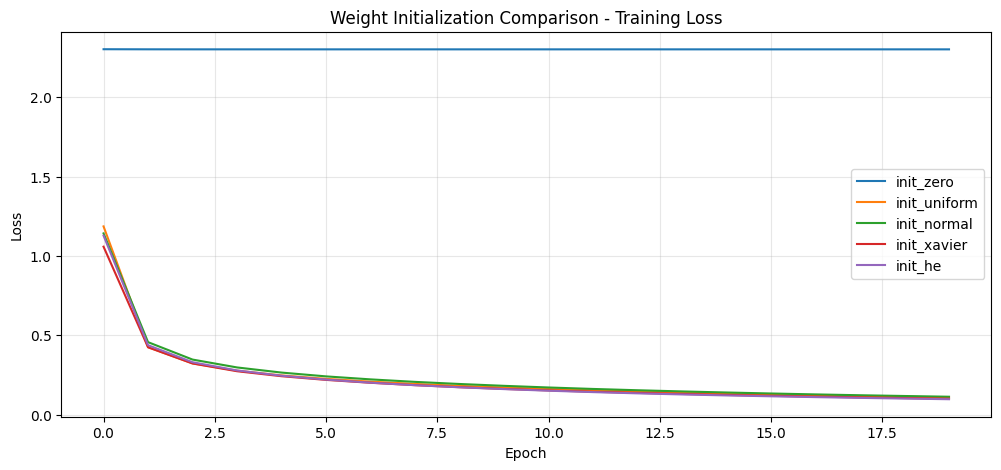

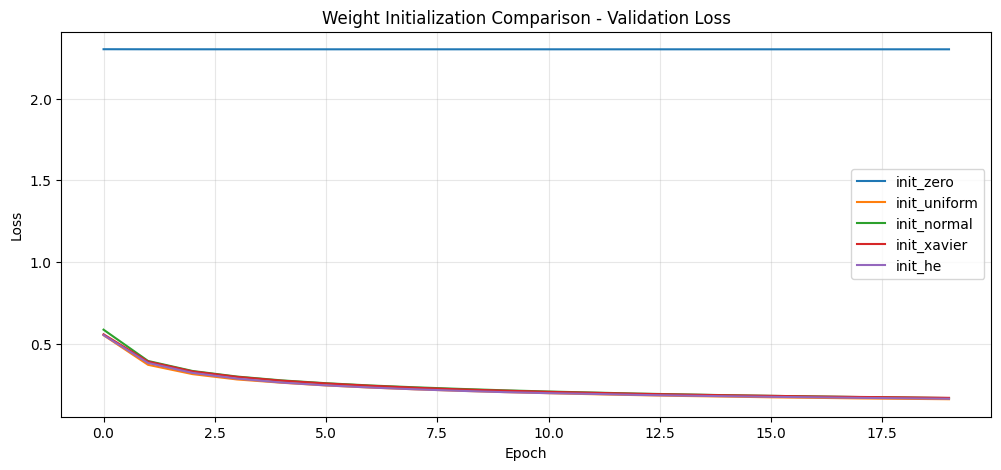

In [26]:
initializers = [
    {'name': 'zero', 'params': {}},
    {'name': 'uniform', 'params': {'low': -0.05, 'high': 0.05}},
    {'name': 'normal', 'params': {'mean': 0, 'std': 0.05}},
    # Bonus initializers
    {'name': 'xavier', 'params': {}},
    {'name': 'he', 'params': {}}
]

fixed_width = 128
fixed_layer_sizes = [784, fixed_width, 10]
fixed_lr = 0.01

init_models = {}
init_histories = {}

print("\n--- Weight Initialization Experiments ---")
for init in initializers:
    name = f"init_{init['name']}"
    
    try:
        print(f"\nTraining model with initializer={init['name']}")
        model = FFNN(
            layer_sizes=fixed_layer_sizes,
            activations=['relu', 'softmax'],
            loss='categorical_cross_entropy',
            weight_initializer=init['name'],
            weight_init_params=init['params'],
            # use_rms_norm=True
        )
        
        history = model.fit(
            X_train, 
            y_train_one_hot,
            batch_size=batch_size,
            learning_rate=fixed_lr,
            epochs=epochs,
            verbose=1,
            validation_data=(X_test, y_test_one_hot),
            gradient_clip=1.0,
            learning_rate_decay=1,
            early_stopping_patience=20
        )
        
        init_models[name] = model
        init_histories[name] = history
        
        # Evaluate model
        print(f"\nEvaluation for {name}:")
        evaluate_model(model, X_test, y_test, y_test_one_hot)
    
        has_nan_weights = any(np.isnan(w).any() for w in model.weights)
        has_nan_gradients = any(np.isnan(g).any() for g in model.weight_gradients)
        
        # Plot weight distribution
        print(f"\nWeight distribution for {name}:")
        if has_nan_weights:
            print("can't plot weight distribution due to nan values")
        else:
            model.plot_weight()
        
        # Plot gradient distribution
        print(f"\nGradient distribution for {name}:")
        if has_nan_gradients:
            print("can't plot gradient distribution due to nan values")
        else:
            model.plot_gradient_distribution()
    
    except Exception as e:
        print(f"Error with initializer {init['name']}: {e}")

# Plot training histories for successful initializers
valid_initializers = init_histories.keys()
if valid_initializers:
    plot_comparison(init_histories, "Weight Initialization Comparison - Training Loss", "train_loss")
    plot_comparison(init_histories, "Weight Initialization Comparison - Validation Loss", "val_loss")

## Comparison


--- Sklearn Comparison ---

Training custom FFNN model


Epoch 1/20: 100%|██████████| 625/625 [00:03<00:00, 199.18it/s]


Epoch 1/20 - 3.24s - loss: 1.2326 - val_loss: 0.7424 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:03<00:00, 198.16it/s]


Epoch 2/20 - 3.26s - loss: 0.5705 - val_loss: 0.4683 - lr: 0.010000


...

Epoch 19/20 - 3.12s - loss: 0.2648 - val_loss: 0.3425 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:03<00:00, 207.89it/s]


Epoch 20/20 - 3.11s - loss: 0.2072 - val_loss: 0.2743 - lr: 0.010000

Evaluation for custom FFNN model:
Custom FFNN test accuracy: 0.9251

Training sklearn MLPClassifier
Iteration 1, loss = 0.32970249
Iteration 2, loss = 0.14736439
Iteration 3, loss = 0.10734225
Iteration 4, loss = 0.07811655
Iteration 5, loss = 0.05810372
Iteration 6, loss = 0.04457727
Iteration 7, loss = 0.03548502
Iteration 8, loss = 0.02882648
Iteration 9, loss = 0.02305152
Iteration 10, loss = 0.01816320
Iteration 11, loss = 0.01455682
Iteration 12, loss = 0.01215816
Iteration 13, loss = 0.01028804
Iteration 14, loss = 0.00887821


c:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Sklearn MLPClassifier test accuracy: 0.9693

Accuracy comparison:
Custom FFNN: 0.9251
Sklearn MLP: 0.9693
Agreement between models: 0.9333


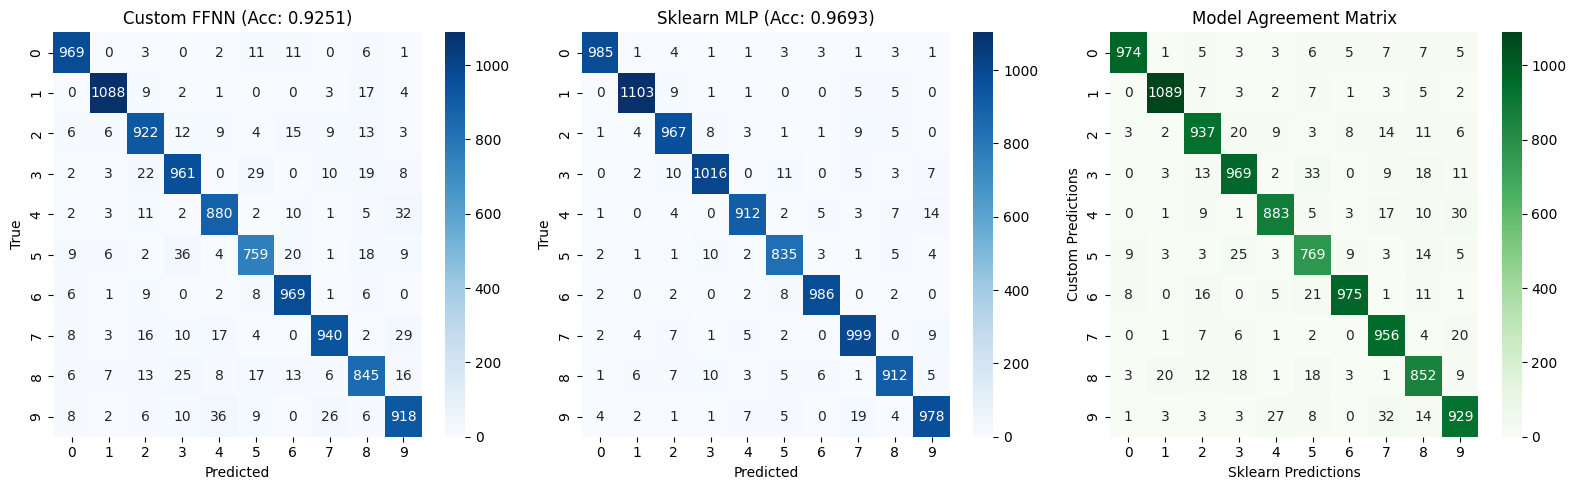

In [ ]:
import pickle

fixed_width = 128
fixed_layer_sizes = [784, fixed_width, 10]
fixed_lr = 0.01
fixed_activation = 'relu'

# custom FFNN model
print("\n--- Sklearn Comparison ---")
print("\nTraining custom FFNN model")
custom_model = FFNN(
    layer_sizes=fixed_layer_sizes,
    activations=[fixed_activation, 'softmax'],
    loss='categorical_cross_entropy',
    weight_initializer='he',
    use_rms_norm=True
)

custom_history = custom_model.fit(
    X_train, 
    y_train_one_hot,
    batch_size=batch_size,
    # learning_rate=fixed_lr,
    learning_rate=fixed_lr,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, y_test_one_hot),
    gradient_clip=1.0,
    # learning_rate_decay=1.0,
    learning_rate_decay=1,
    early_stopping_patience=None
)

# Evaluate custom model
print("\nEvaluation for custom FFNN model:")
custom_pred = custom_model.predict(X_test)
custom_pred_class = np.argmax(custom_pred, axis=1)
custom_acc = accuracy_score(y_test, custom_pred_class)
print(f"Custom FFNN test accuracy: {custom_acc:.4f}")

# sklearn model
print("\nTraining sklearn MLPClassifier")
sklearn_model = MLPClassifier(
    hidden_layer_sizes=(fixed_width,),
    activation=fixed_activation,
    solver='sgd',
    alpha=0.0001,  # L2
    batch_size=batch_size,
    learning_rate_init=fixed_lr,
    max_iter=epochs,
    shuffle=True,
    random_state=42,
    verbose=True
)

sklearn_model.fit(X_train, y_train)

# Evaluate sklearn model
sklearn_pred = sklearn_model.predict(X_test)
sklearn_acc = accuracy_score(y_test, sklearn_pred)
print(f"Sklearn MLPClassifier test accuracy: {sklearn_acc:.4f}")

# Compare models
print(f"\nAccuracy comparison:")
print(f"Custom FFNN: {custom_acc:.4f}")
print(f"Sklearn MLP: {sklearn_acc:.4f}")

# Compare predictions
agreement = np.mean(custom_pred_class == sklearn_pred)
print(f"Agreement between models: {agreement:.4f}")

plt.figure(figsize=(16, 5))

# Custom FFNN confusion matrix
plt.subplot(1, 3, 1)
custom_cm = confusion_matrix(y_test, custom_pred_class)
sns.heatmap(custom_cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Custom FFNN (Acc: {custom_acc:.4f})')
plt.xlabel('Predicted')
plt.ylabel('True')

# Sklearn model confusion matrix
plt.subplot(1, 3, 2)
sklearn_cm = confusion_matrix(y_test, sklearn_pred)
sns.heatmap(sklearn_cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Sklearn MLP (Acc: {sklearn_acc:.4f})')
plt.xlabel('Predicted')
plt.ylabel('True')

# Plot agreement
plt.subplot(1, 3, 3)
agreement_cm = confusion_matrix(custom_pred_class, sklearn_pred)
sns.heatmap(agreement_cm, annot=True, fmt='d', cmap='Greens')
plt.title('Model Agreement Matrix')
plt.xlabel('Sklearn Predictions')
plt.ylabel('Custom Predictions')

plt.tight_layout()
plt.show()

In [ ]:
# Contoh pemakaian save
MODELS_DIR = os.path.abspath("../tests")
if not os.path.exists(MODELS_DIR):
    os.makedirs(MODELS_DIR)
filepath = os.path.join(MODELS_DIR, "comparison" + ".pkl")
custom_model.save(filepath)

Starting save process to d:\Personal Doc\Projects\College\Tubes_ML\tests\comparison.pkl
layer_sizes: [784, 128, 128, 128, 10]
Number of weight matrices: 4
Weight matrix 0 shape: (784, 128)
Weight matrix 1 shape: (128, 128)
Weight matrix 2 shape: (128, 128)
Weight matrix 3 shape: (128, 10)
Number of bias vectors: 4
Bias vector 0 shape: (128,)
Bias vector 1 shape: (128,)
Bias vector 2 shape: (128,)
Bias vector 3 shape: (10,)
Number of activation functions: 4
Activation 0: ReLU
Activation 1: ReLU
Activation 2: ReLU
Activation 3: Softmax
Loss function: Categorical Cross-Entropy
RMS norm enabled, normalizers: 4
Model data prepared successfully, attempting to save...
Model saved successfully!


In [ ]:
# Contoh pemakaian load
loaded_model = FFNN.load(filepath)

Starting load process from d:\Personal Doc\Projects\College\Tubes_ML\tests\comparison.pkl
File loaded. Model data type: <class 'dict'>
Model data is a dictionary, checking contents...
layer_sizes: list with 5 items
weights: list with 4 items
biases: list with 4 items
loss: <class 'type'>
activations: list with 4 items
use_rms_norm: <class 'bool'>
Layer sizes: [784, 128, 128, 128, 10]
Creating minimal model with 5 layers
Basic model created. Setting saved parameters...
Setting weights: 4 matrices
Setting biases: 4 vectors
Setting loss function
Setting activations: 4 functions
Setting RMS norm: True
Model loaded successfully!


d:\Personal Doc\Projects\College\Tubes_ML\src\models\utils.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


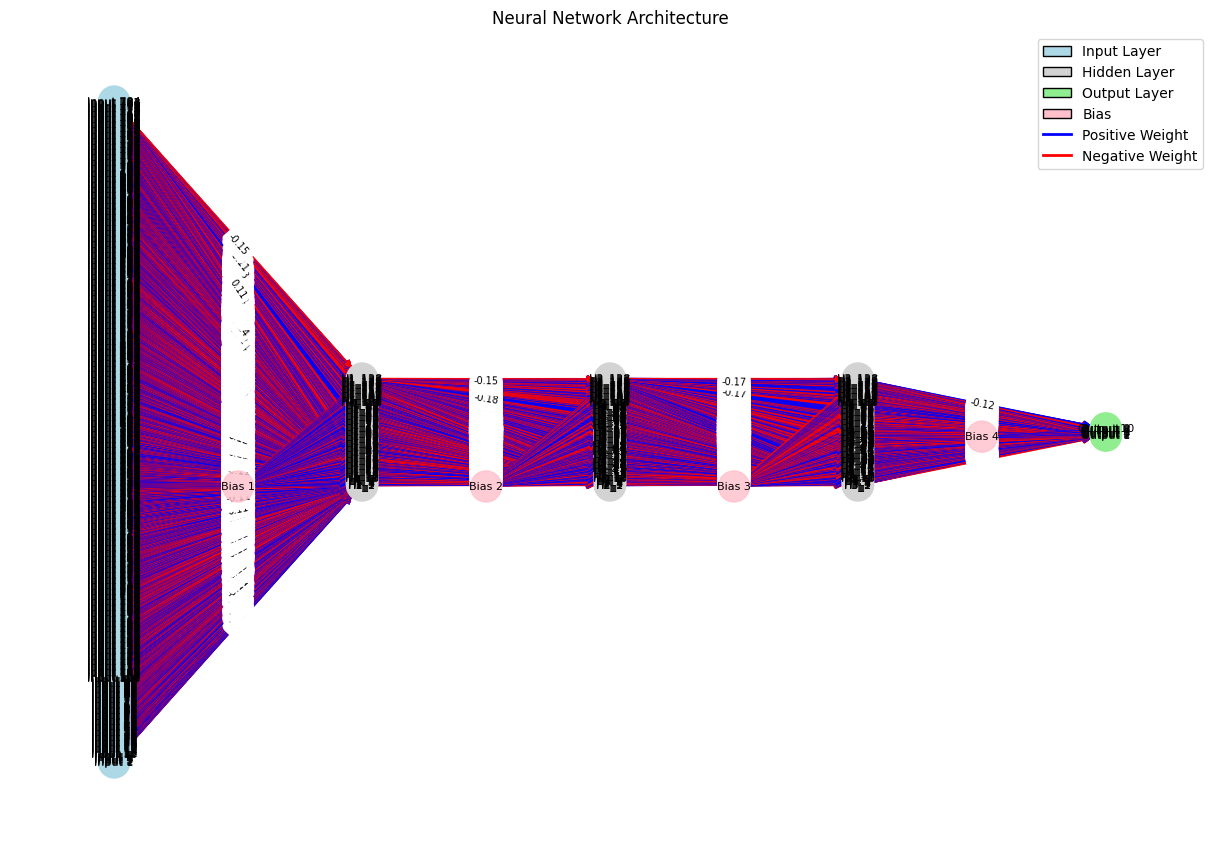

In [ ]:
# Contoh display FFNN
loaded_model.plot_model()

## Regularizers


--- Regularization Experiments ---

Training model with regularizer=None


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 248.41it/s]


Epoch 1/20 - 2.57s - loss: 2.5390 - val_loss: 2.2966 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 265.06it/s]


Epoch 2/20 - 2.42s - loss: 2.0623 - val_loss: 1.9011 - lr: 0.009800


...

Epoch 18/20 - 2.50s - loss: 0.6890 - val_loss: 0.7024 - lr: 0.007093


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 276.55it/s]


Epoch 19/20 - 2.31s - loss: 0.6727 - val_loss: 0.6870 - lr: 0.006951


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 262.86it/s]


Epoch 20/20 - 2.43s - loss: 0.6580 - val_loss: 0.6731 - lr: 0.006812

Evaluation for reg_None:
Test accuracy: 0.8247


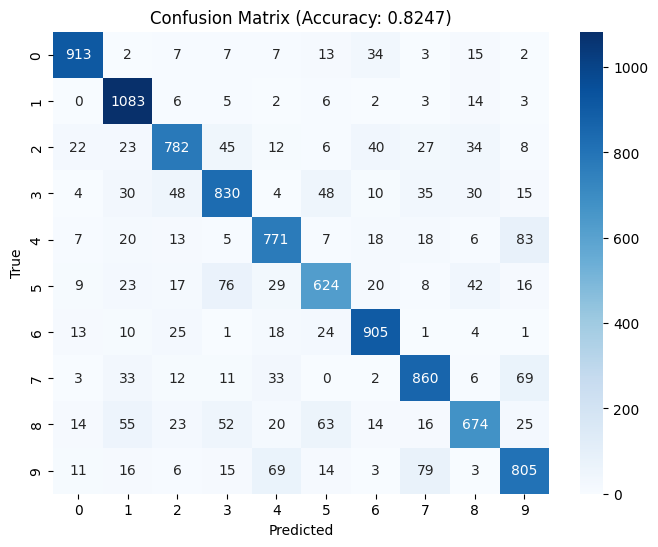


Weight distribution for reg_None:


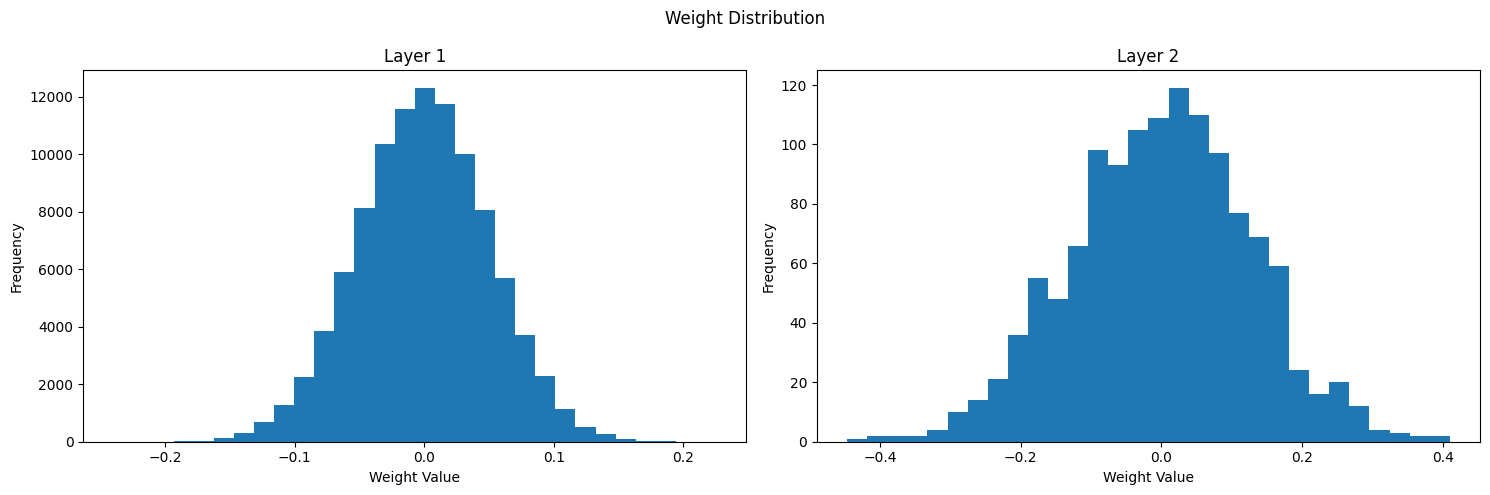


Gradient distribution for reg_None:


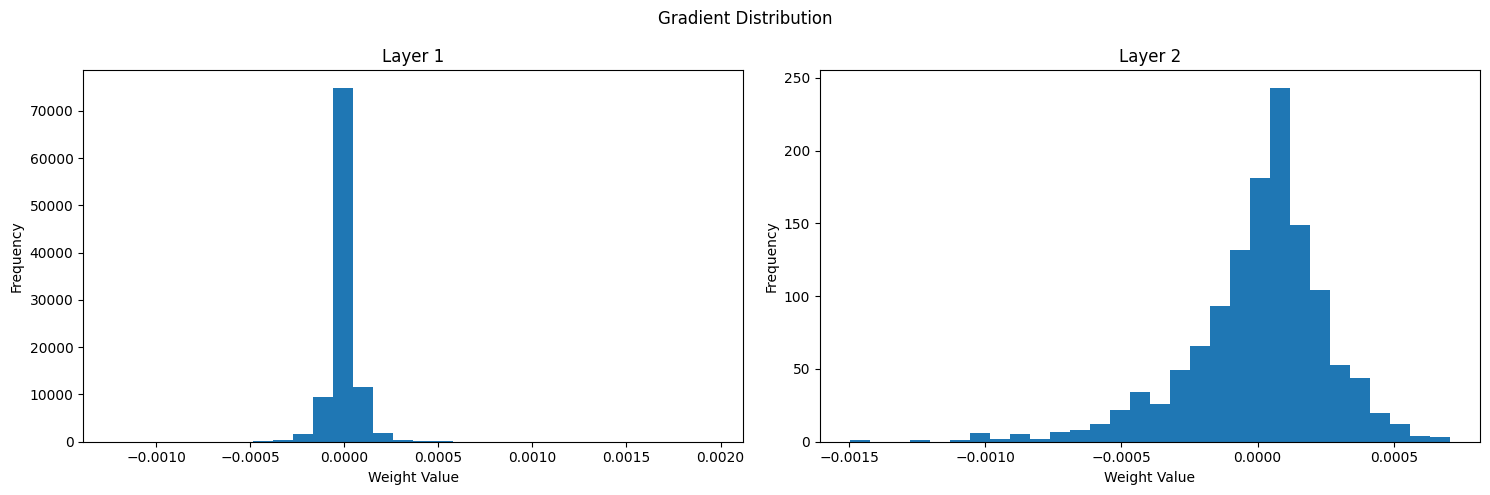


Training model with regularizer=L1


Epoch 1/20: 100%|██████████| 625/625 [00:03<00:00, 202.85it/s]


Epoch 1/20 - 3.14s - loss: 35.4831 - val_loss: 2.5220 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 235.44it/s]


Epoch 2/20 - 2.71s - loss: 21.2463 - val_loss: 2.3388 - lr: 0.009800


...

Epoch 7/20 - 2.68s - loss: 2.8834 - val_loss: 2.2978 - lr: 0.008858


Epoch 8/20: 100%|██████████| 625/625 [00:02<00:00, 234.52it/s]


Epoch 8/20 - 2.72s - loss: 2.6233 - val_loss: 2.3014 - lr: 0.008681


Epoch 9/20: 100%|██████████| 625/625 [00:02<00:00, 236.82it/s]


Early stopping at epoch 9

Evaluation for reg_L1:
Test accuracy: 0.1223


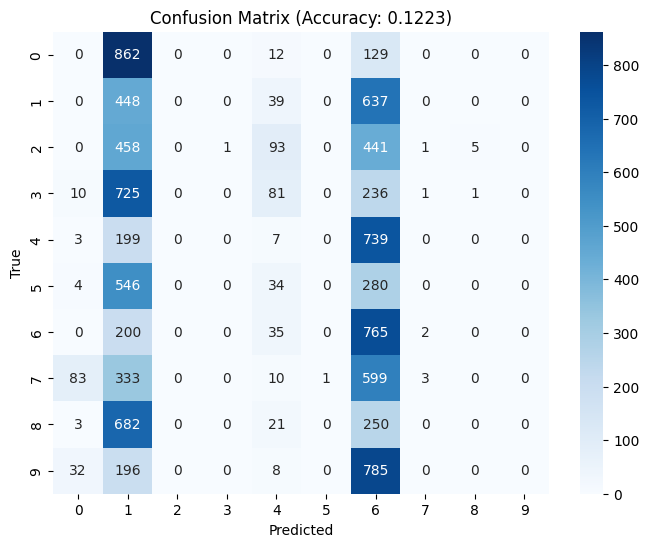


Weight distribution for reg_L1:


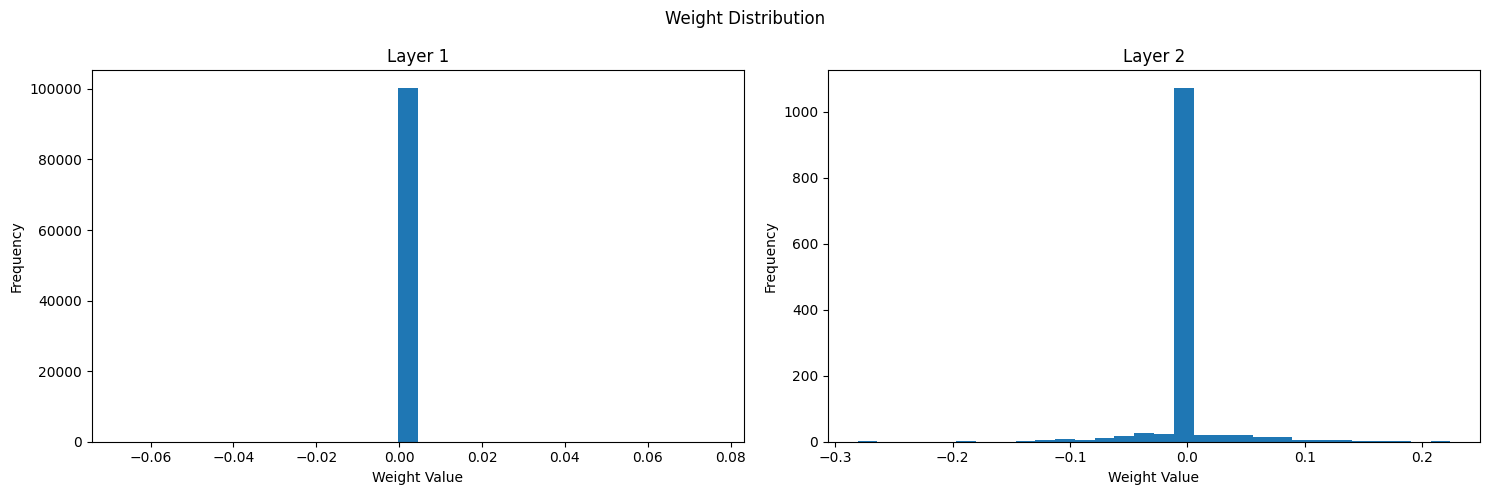


Gradient distribution for reg_L1:


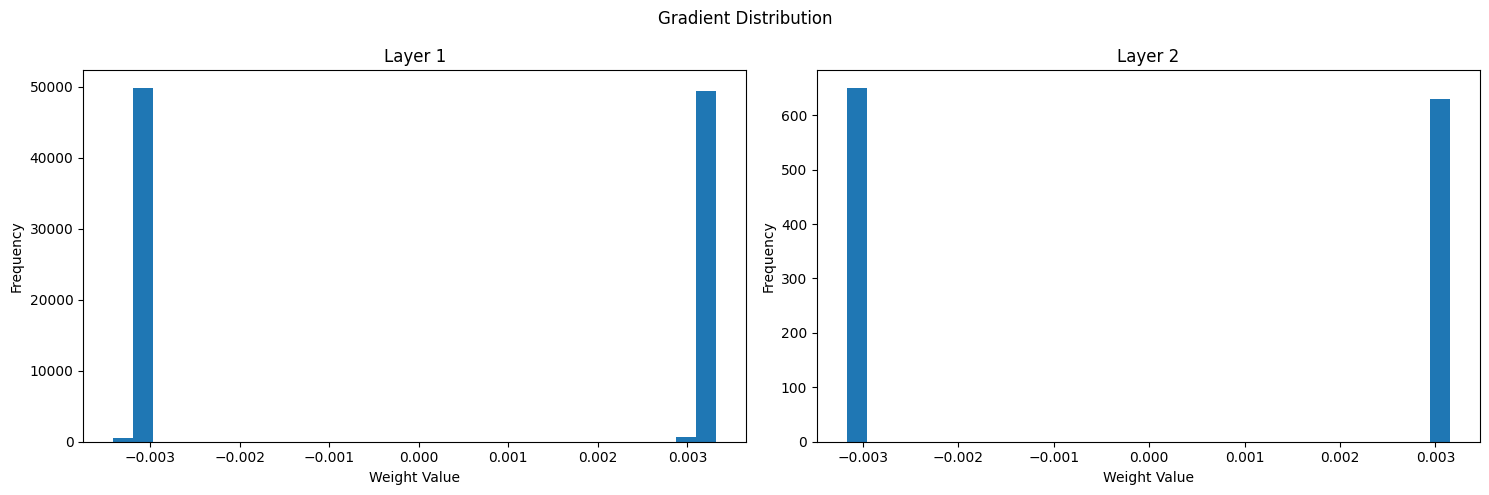


Training model with regularizer=L2


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 274.60it/s]


Epoch 1/20 - 2.38s - loss: 3.8254 - val_loss: 2.2695 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 271.19it/s]


Epoch 2/20 - 2.35s - loss: 3.2184 - val_loss: 1.9346 - lr: 0.009800


...

Epoch 14/20 - 2.45s - loss: 1.7111 - val_loss: 1.4100 - lr: 0.007690


Epoch 15/20: 100%|██████████| 625/625 [00:02<00:00, 271.74it/s]


Epoch 15/20 - 2.35s - loss: 1.6901 - val_loss: 1.4172 - lr: 0.007536


Epoch 16/20: 100%|██████████| 625/625 [00:02<00:00, 269.63it/s]


Early stopping at epoch 16

Evaluation for reg_L2:
Test accuracy: 0.7675


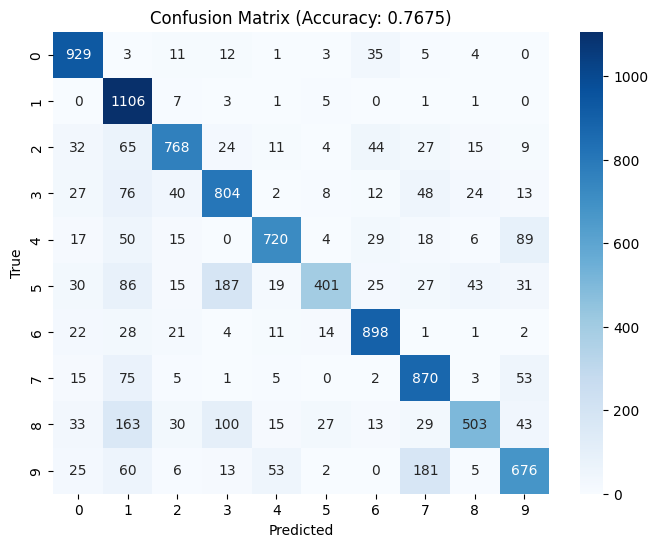


Weight distribution for reg_L2:


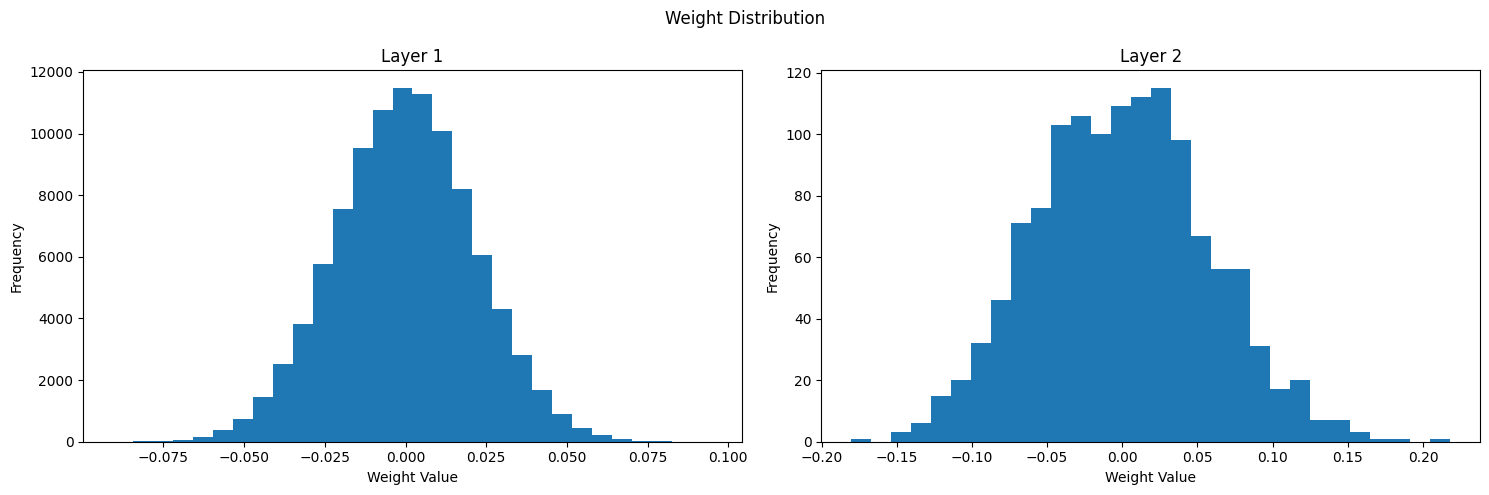


Gradient distribution for reg_L2:


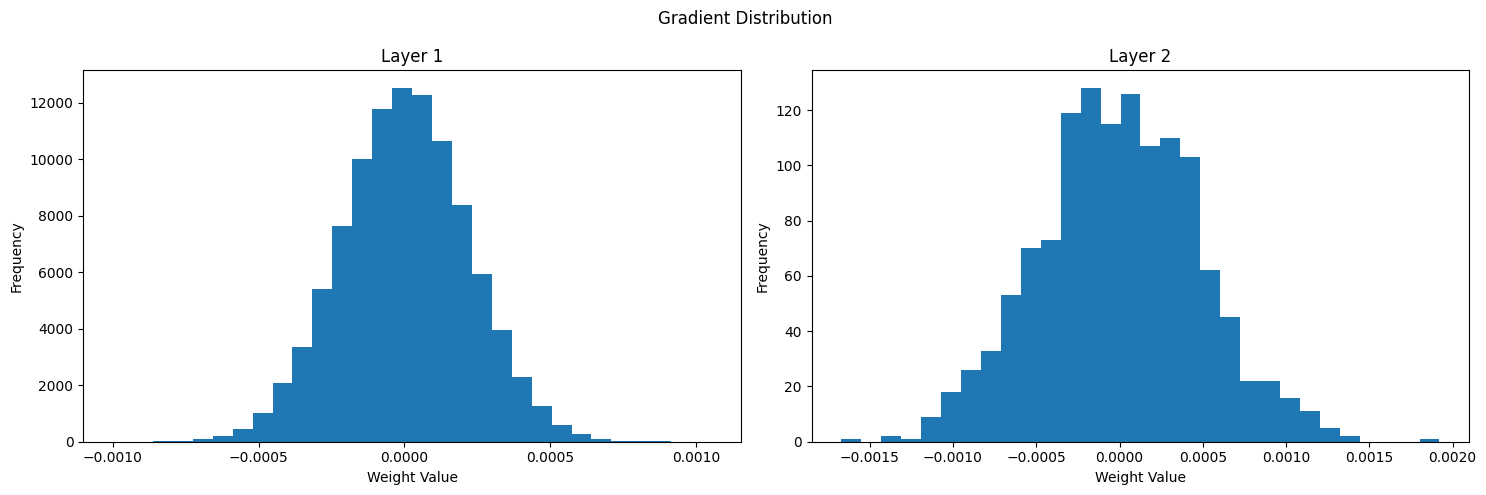

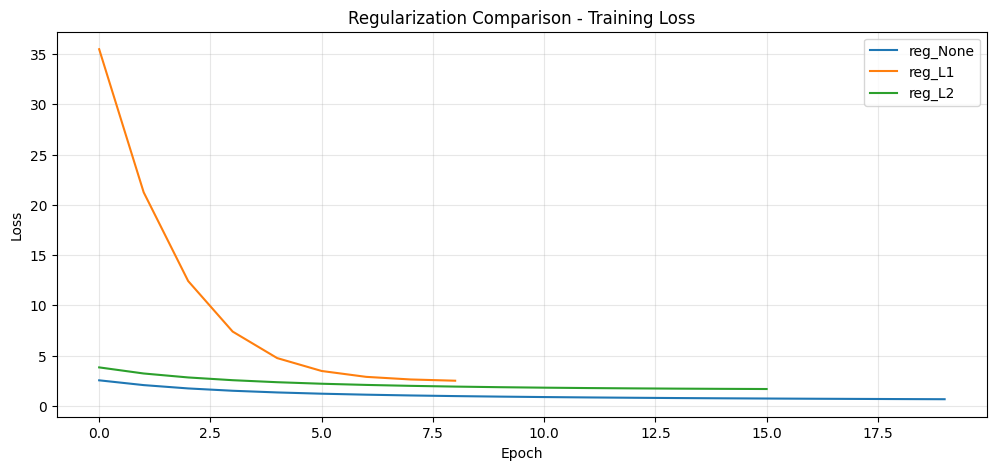

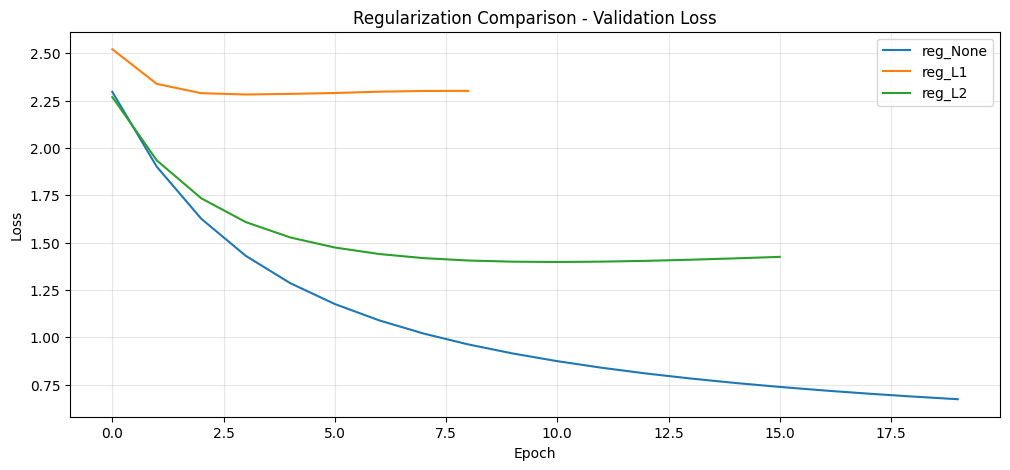

In [ ]:
# Define regularizers to test
regularizers = [
    {'name': 'None', 'regularizer': None},
    {'name': 'L1', 'regularizer': 'l1'},
    {'name': 'L2', 'regularizer': 'l2'}
]

fixed_width = 128
fixed_layer_sizes = [784, fixed_width, 10]
fixed_lr = 0.01

reg_models = {}
reg_histories = {}

print("\n--- Regularization Experiments ---")
for reg in regularizers:
    name = f"reg_{reg['name']}"
    
    print(f"\nTraining model with regularizer={reg['name']}")
    model = FFNN(
        layer_sizes=fixed_layer_sizes,
        activations=['relu', 'softmax'],
        loss='categorical_cross_entropy',
        weight_initializer='he',
        regularizer=reg['regularizer'],
        # use_rms_norm=True
    )
    
    history = model.fit(
        X_train, 
        y_train_one_hot,
        batch_size=batch_size,
        learning_rate=fixed_lr,
        epochs=epochs,
        verbose=1,
        validation_data=(X_test, y_test_one_hot),
        gradient_clip=1.0,
        learning_rate_decay=0.98,
        early_stopping_patience=5
    )
    
    reg_models[name] = model
    reg_histories[name] = history
    
    # Evaluate model
    print(f"\nEvaluation for {name}:")
    evaluate_model(model, X_test, y_test, y_test_one_hot)
    
    # Check for NaN values before plotting
    has_nan_weights = any(np.isnan(w).any() for w in model.weights)
    has_nan_gradients = any(np.isnan(g).any() for g in model.weight_gradients)
    
    # Plot weight distribution
    print(f"\nWeight distribution for {name}:")
    if has_nan_weights:
        print("can't plot weight distribution due to nan values")
    else:
        model.plot_weight()
    
    # Plot gradient distribution
    print(f"\nGradient distribution for {name}:")
    if has_nan_gradients:
        print("can't plot gradient distribution due to nan values")
    else:
        model.plot_gradient_distribution()

# Plot training histories
plot_comparison(reg_histories, "Regularization Comparison - Training Loss", "train_loss")
plot_comparison(reg_histories, "Regularization Comparison - Validation Loss", "val_loss")

## RMSNorm


--- Normalization Experiments ---

Training model with normalization=None


Epoch 1/20: 100%|██████████| 625/625 [00:03<00:00, 189.16it/s]


Epoch 1/20 - 3.39s - loss: 2.3867 - val_loss: 2.2215 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:03<00:00, 189.68it/s]


Epoch 2/20 - 3.38s - loss: 2.1139 - val_loss: 2.0271 - lr: 0.009000


...

Epoch 18/20 - 3.41s - loss: 1.1225 - val_loss: 1.1409 - lr: 0.001668


Epoch 19/20: 100%|██████████| 625/625 [00:03<00:00, 188.76it/s]


Epoch 19/20 - 3.40s - loss: 1.1090 - val_loss: 1.1285 - lr: 0.001501


Epoch 20/20: 100%|██████████| 625/625 [00:03<00:00, 189.91it/s]


Epoch 20/20 - 3.38s - loss: 1.0971 - val_loss: 1.1175 - lr: 0.001351

Evaluation for norm_None:
Test accuracy: 0.6871


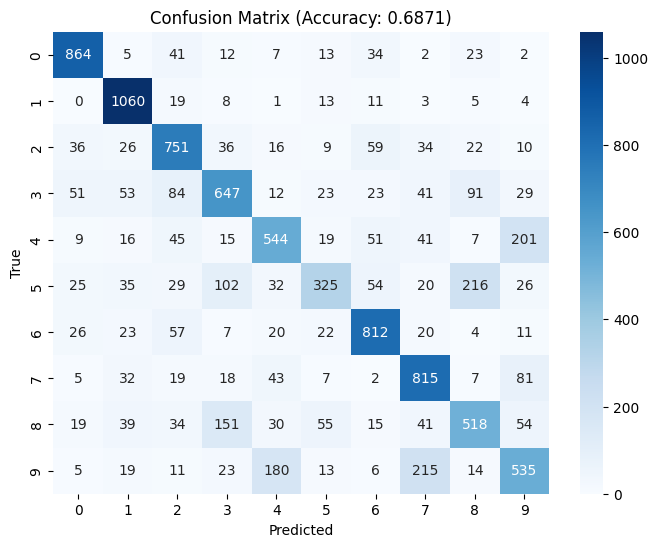


Weight distribution for norm_None:


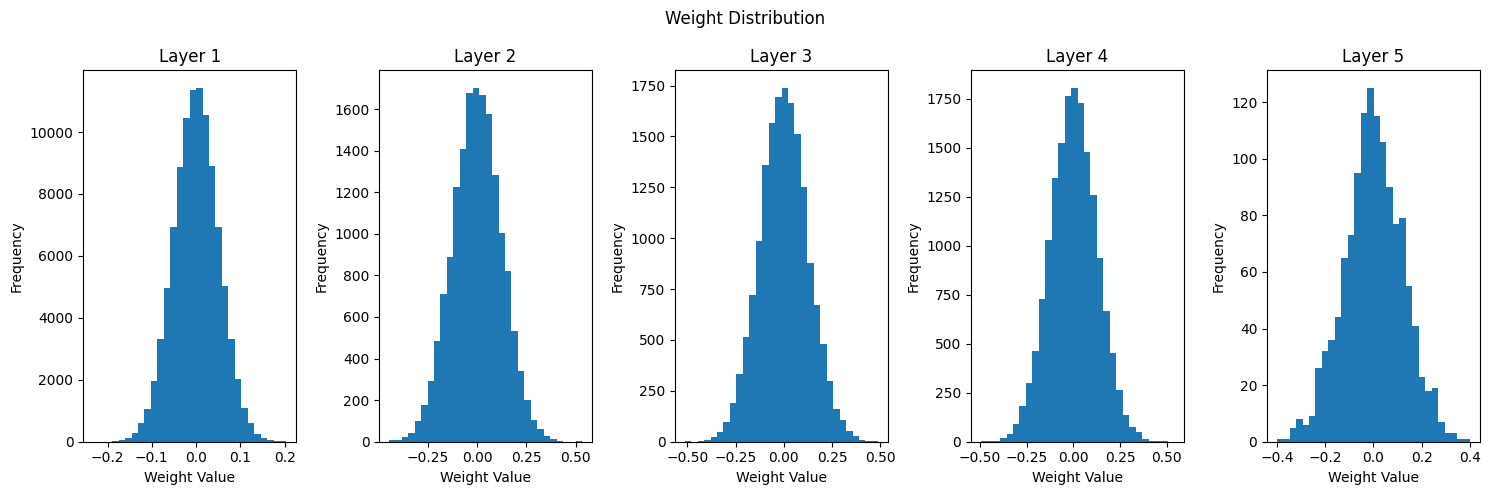


Gradient distribution for norm_None:


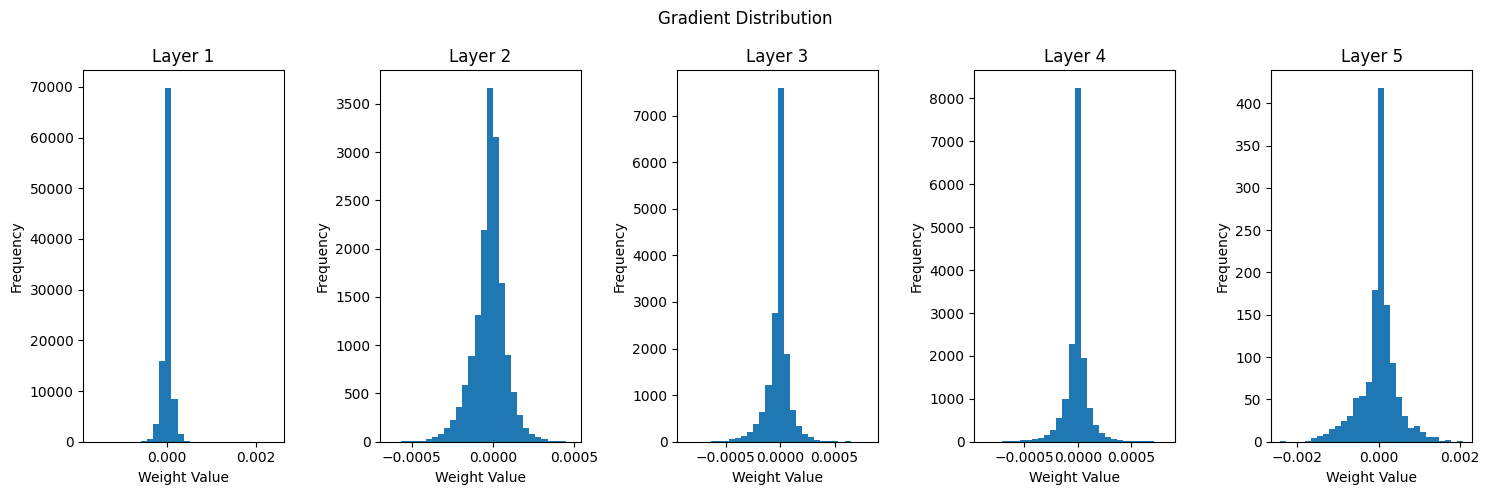


Training model with normalization=RMSNorm


Epoch 1/20: 100%|██████████| 625/625 [00:03<00:00, 173.18it/s]


Epoch 1/20 - 3.74s - loss: 2.4391 - val_loss: 2.2553 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:03<00:00, 172.65it/s]


Epoch 2/20 - 3.75s - loss: 2.1131 - val_loss: 1.9957 - lr: 0.009000


...

Epoch 18/20 - 3.63s - loss: 0.8771 - val_loss: 0.9045 - lr: 0.001668


Epoch 19/20: 100%|██████████| 625/625 [00:03<00:00, 163.61it/s]


Epoch 19/20 - 3.96s - loss: 0.8605 - val_loss: 0.8895 - lr: 0.001501


Epoch 20/20: 100%|██████████| 625/625 [00:03<00:00, 176.06it/s]


Epoch 20/20 - 3.67s - loss: 0.8462 - val_loss: 0.8761 - lr: 0.001351

Evaluation for norm_RMSNorm:
Test accuracy: 0.7275


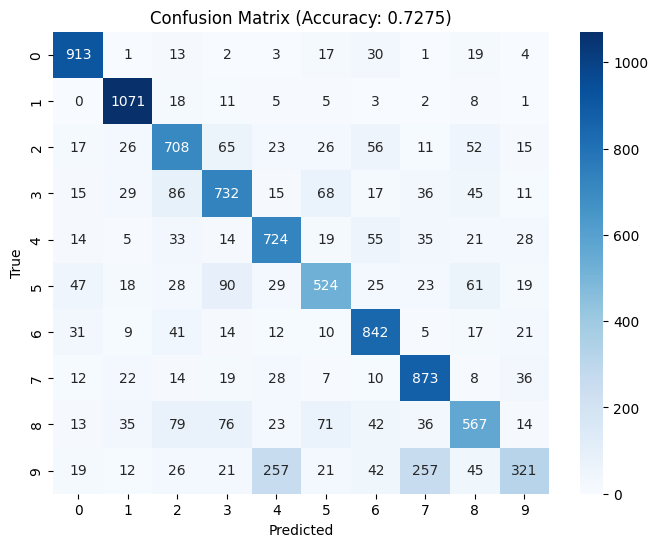


Weight distribution for norm_RMSNorm:


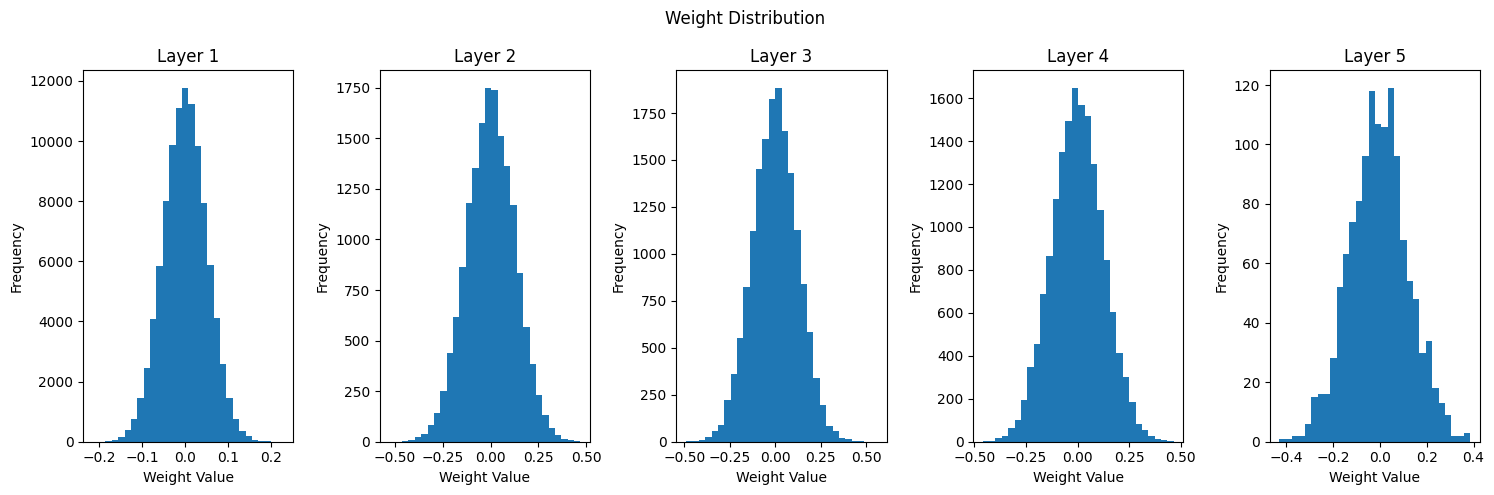


Gradient distribution for norm_RMSNorm:


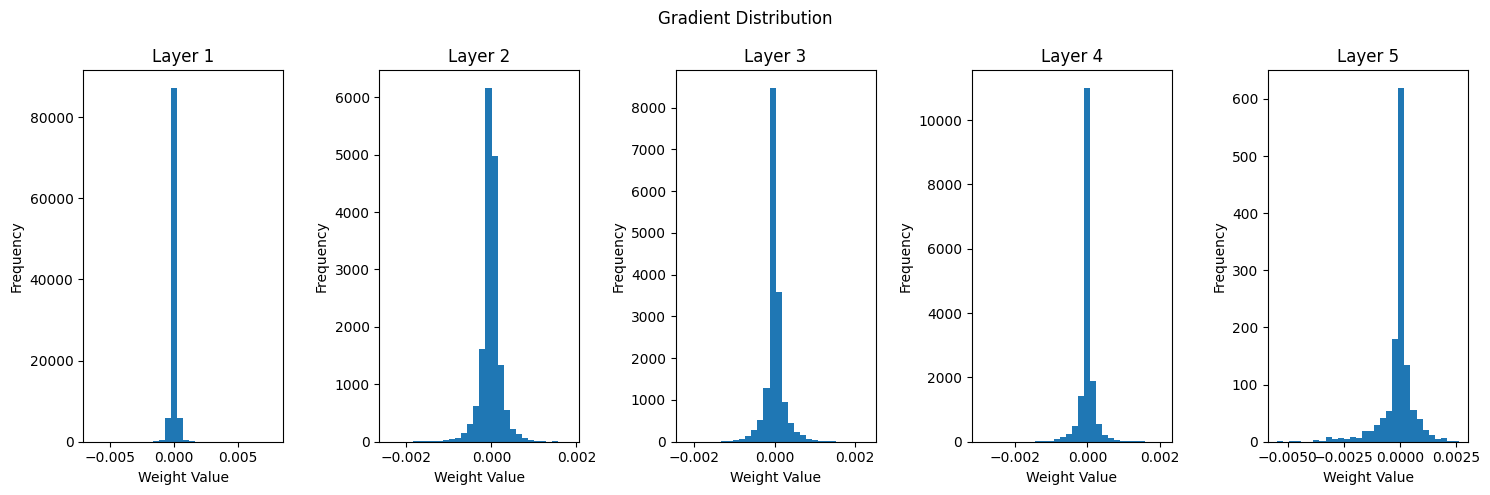

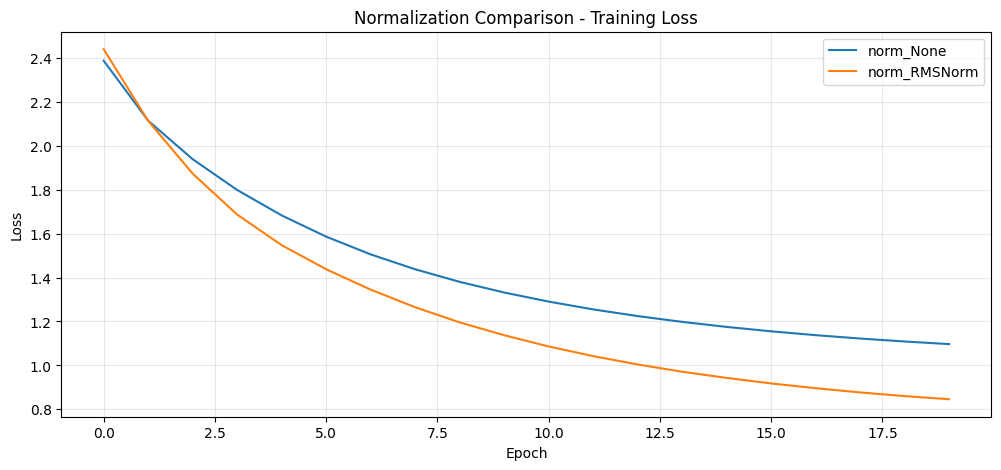

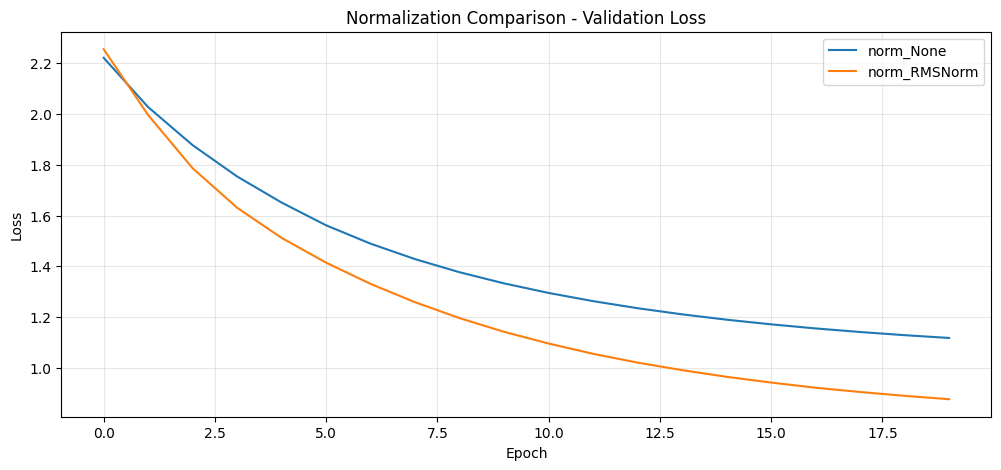

In [ ]:
# normalization options
normalizations = [
    {'name': 'None', 'use_rms_norm': False},
    {'name': 'RMSNorm', 'use_rms_norm': True}
]

fixed_width = 128
fixed_layer_sizes = [784, fixed_width, fixed_width, fixed_width, fixed_width, 10]
fixed_lr = 0.01

norm_models = {}
norm_histories = {}

print("\n--- Normalization Experiments ---")
for norm in normalizations:
    name = f"norm_{norm['name']}"
    
    print(f"\nTraining model with normalization={norm['name']}")
    model = FFNN(
        layer_sizes=fixed_layer_sizes,
        activations=['relu', 'relu', 'relu', 'relu', 'softmax'],
        loss='categorical_cross_entropy',
        weight_initializer='he',
        use_rms_norm=norm['use_rms_norm']
    )
    
    history = model.fit(
        X_train, 
        y_train_one_hot,
        batch_size=batch_size,
        learning_rate=fixed_lr,
        epochs=epochs,
        verbose=1,
        validation_data=(X_test, y_test_one_hot),
        gradient_clip=1.0,
        learning_rate_decay=0.9,
        early_stopping_patience=5
    )
    
    # Store model and history
    norm_models[name] = model
    norm_histories[name] = history
    
    # Evaluate model
    print(f"\nEvaluation for {name}:")
    evaluate_model(model, X_test, y_test, y_test_one_hot)
    
    # Check for NaN values before plotting
    has_nan_weights = any(np.isnan(w).any() for w in model.weights)
    has_nan_gradients = any(np.isnan(g).any() for g in model.weight_gradients)
    
    # Plot weight distribution
    print(f"\nWeight distribution for {name}:")
    if has_nan_weights:
        print("can't plot weight distribution due to nan values")
    else:
        model.plot_weight()
    
    # Plot gradient distribution
    print(f"\nGradient distribution for {name}:")
    if has_nan_gradients:
        print("can't plot gradient distribution due to nan values")
    else:
        model.plot_gradient_distribution()

# Plot training histories
plot_comparison(norm_histories, "Normalization Comparison - Training Loss", "train_loss")
plot_comparison(norm_histories, "Normalization Comparison - Validation Loss", "val_loss")

# 1. **Depth and Width**: BAGUS OR NO
# 2. **Activation Functions**: BAGUS OR NO
# 3. **Learning Rate**: BAGUS OR NO
# 4. **Weight Initialization**: BAGUS OR NO
# 5. **Comparison with sklearn**: BAGUS OR NO
# 6. **Regularization (Bonus)**: BAGUS OR NO
# 7. **RMSNorm (Bonus)**: BAGUS OR NO